In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from scipy import stats
from prophet import Prophet

In [31]:

#load parquet file
df = pd.read_parquet('taxi-dataset.parquet')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3152677 entries, 0 to 3152676
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

In [32]:
#get column names
print(df.columns)

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')


In [33]:
#show first 5 rows
print(df.head)

<bound method NDFrame.head of          VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0               1  2022-08-01 00:17:39   2022-08-01 00:19:58              1.0   
1               1  2022-08-01 00:26:06   2022-08-01 00:31:55              1.0   
2               1  2022-08-01 00:45:49   2022-08-01 00:59:29              1.0   
3               1  2022-08-01 00:05:49   2022-08-01 00:25:42              1.0   
4               1  2022-08-01 00:36:29   2022-08-01 00:51:29              1.0   
...           ...                  ...                   ...              ...   
3152672         2  2022-08-31 23:40:00   2022-08-31 23:49:00              NaN   
3152673         1  2022-08-31 23:11:41   2022-08-31 23:21:23              NaN   
3152674         2  2022-08-31 23:02:53   2022-08-31 23:12:13              NaN   
3152675         2  2022-08-31 23:54:16   2022-08-31 23:56:41              NaN   
3152676         2  2022-08-31 23:40:44   2022-08-31 23:40:53              NaN  

In [34]:
#calculate number of null values in each column
print(df.isnull().sum())

#drop rows with null values
df = df.dropna()

VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          93174
trip_distance                0
RatecodeID               93174
store_and_fwd_flag       93174
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     93174
airport_fee              93174
dtype: int64


In [35]:
# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [36]:
def load_and_prepare_data(file_path):
    """
    Load and prepare the taxi dataset
    """
    print("Loading data...")
    # Load the dataset
    df = pd.read_parquet(file_path)
    
    # Check basic information
    print("\nDataset Shape:", df.shape)
    print("\nColumns with missing values:")
    print(df.isnull().sum())

    # Dropping trips with zero/missing distance
    df = df[(df['trip_distance'] > 0)]
    
    # Convert datetime columns
    df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
    df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
    
    # Calculate trip duration in minutes
    df['trip_duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60
    
    # Extract time components for time series analysis
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
    df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
    df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
    df['pickup_month'] = df['tpep_pickup_datetime'].dt.month
    df['pickup_year'] = df['tpep_pickup_datetime'].dt.year
    df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek  # 0=Monday, 6=Sunday
    
    # Calculate tip percentage
    df['tip_percentage'] = np.where(df['fare_amount'] > 0, 
                                    (df['tip_amount'] / df['fare_amount']) * 100, 
                                    0)
    
    # Map payment types if needed (based on NYC TLC data)
    payment_type_map = {
        1: 'Credit Card',
        2: 'Cash',
        3: 'No Charge',
        4: 'Dispute',
        5: 'Unknown',
        6: 'Voided trip'
    }
    df['payment_type_desc'] = df['payment_type'].map(payment_type_map)
    
    # Handle outliers for numerical columns
    for col in ['trip_distance', 'fare_amount', 'trip_duration']:
        if col in df.columns:
            q1 = df[col].quantile(0.01)
            q3 = df[col].quantile(0.99)
            df[f'{col}_filtered'] = df[col].clip(q1, q3)
    
    return df

In [37]:
def analyze_missing_values(df):
    """
    Analyze and visualize missing values
    """
    print("\n--- Missing Values Analysis ---")
    missing = df.isnull().sum().sort_values(ascending=False)
    missing_percent = (df.isnull().sum() / df.shape[0] * 100).sort_values(ascending=False)
    
    missing_data = pd.concat([missing, missing_percent], axis=1, keys=['Total', 'Percent'])
    print(missing_data[missing_data['Total'] > 0])
    
    # Only plot if there are missing values
    if missing_data['Total'].sum() > 0:
        plt.figure(figsize=(10, 6))
        missing_data[missing_data['Total'] > 0]['Percent'].plot(kind='bar')
        plt.title('Percentage of Missing Values by Feature')
        plt.ylabel('Percentage')
        plt.xlabel('Features')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig('missing_values.png')
        print("Missing values chart saved as 'missing_values.png'")

In [38]:
def plot_time_series_patterns(df):
    """
    Create time series plots to analyze patterns
    """
    print("\n--- Time Series Patterns Analysis ---")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes[1, 1].axis('off')
    
    # 1. Trips by hour of day
    hourly_trips = df.groupby('pickup_hour').size()
    sns.barplot(x=hourly_trips.index, y=hourly_trips.values, ax=axes[0, 0])
    axes[0, 0].set_title('Number of Trips by Hour of Day')
    axes[0, 0].set_xlabel('Hour of Day')
    axes[0, 0].set_ylabel('Number of Trips')
    
    # 2. Trips by day of week
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_trips = df.groupby('pickup_day').size().reindex(day_order)
    sns.barplot(x=day_trips.index, y=day_trips.values, ax=axes[0, 1])
    axes[0, 1].set_title('Number of Trips by Day of Week')
    axes[0, 1].set_xlabel('Day of Week')
    axes[0, 1].set_ylabel('Number of Trips')
    axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45)
    
    # 3. Average Fare by Hour
    hourly_fare = df.groupby('pickup_hour')['fare_amount'].mean()
    sns.lineplot(x=hourly_fare.index, y=hourly_fare.values, marker='o', ax=axes[1, 0])
    axes[1, 0].set_title('Average Fare by Hour of Day')
    axes[1, 0].set_xlabel('Hour of Day')
    axes[1, 0].set_ylabel('Average Fare ($)')

    plt.tight_layout()
    plt.savefig('time_series_patterns.png')
    print("Time series patterns saved as 'time_series_patterns.png'")
    
    # Heat map for hourly patterns by day of week
    plt.figure(figsize=(14, 8))
    hourly_day_trips = df.groupby(['pickup_dayofweek', 'pickup_hour']).size().unstack()
    # Reindex to ensure all days and hours are included, filling missing with 0
    all_hours = list(range(24))
    all_days = list(range(7))
    hourly_day_trips = hourly_day_trips.reindex(all_days, fill_value=0).reindex(columns=all_hours, fill_value=0)
    
    # Create the heatmap
    sns.heatmap(hourly_day_trips, cmap='viridis', annot=False, fmt='g')
    plt.title('Trip Frequency by Day of Week and Hour')
    plt.xlabel('Hour of Day')
    plt.ylabel('Day of Week')
    # Change y-axis labels to day names
    day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    plt.yticks(np.arange(7) + 0.5, day_names)
    plt.tight_layout()
    plt.savefig('day_hour_heatmap.png')
    print("Day-hour heatmap saved as 'day_hour_heatmap.png'")

In [39]:
def analyze_trip_metrics(df):
    """
    Analyze key trip metrics: distance, duration, fare, etc.
    """
    print("\n--- Trip Metrics Analysis ---")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # 1. Trip distance distribution
    sns.histplot(df['trip_distance_filtered'], bins=30, kde=True, ax=axes[0, 0])
    axes[0, 0].set_title('Trip Distance Distribution')
    axes[0, 0].set_xlabel('Trip Distance (miles)')
    
    # 2. Trip duration distribution
    if 'trip_duration_filtered' in df.columns:
        sns.histplot(df['trip_duration_filtered'], bins=30, kde=True, ax=axes[0, 1])
        axes[0, 1].set_title('Trip Duration Distribution')
        axes[0, 1].set_xlabel('Trip Duration (minutes)')
    
    # 3. Fare amount distribution
    sns.histplot(df['fare_amount_filtered'], bins=30, kde=True, ax=axes[1, 0])
    axes[1, 0].set_title('Fare Amount Distribution')
    axes[1, 0].set_xlabel('Fare Amount ($)')
    
    # 4. Scatter plot of Distance vs. Fare
    sns.scatterplot(x='trip_distance_filtered', y='fare_amount_filtered', 
                    data=df, alpha=0.3, ax=axes[1, 1])
    axes[1, 1].set_title('Fare vs. Distance')
    axes[1, 1].set_xlabel('Trip Distance (miles)')
    axes[1, 1].set_ylabel('Fare Amount ($)')
    
    # Calculate and display correlation
    correlation = df['trip_distance_filtered'].corr(df['fare_amount_filtered'])
    axes[1, 1].annotate(f'Correlation: {correlation:.2f}', 
                        xy=(0.05, 0.95), xycoords='axes fraction',
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('trip_metrics.png')
    print("Trip metrics analysis saved as 'trip_metrics.png'")
    
    # Payment Type Analysis
    plt.figure(figsize=(10, 6))
    payment_counts = df['payment_type_desc'].value_counts()
    plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', 
            startangle=90, shadow=True)
    plt.axis('equal')
    plt.title('Payment Method Distribution')
    plt.tight_layout()
    plt.savefig('payment_types.png')
    print("Payment types chart saved as 'payment_types.png'")
    
    # Tip Percentage Analysis
    plt.figure(figsize=(10, 6))
    valid_tips = df[df['payment_type'] == 1]['tip_percentage'].clip(0, 50)  # Focus on credit card payments
    sns.histplot(valid_tips, bins=25, kde=True)
    plt.axvline(x=valid_tips.mean(), color='r', linestyle='--', 
                label=f'Mean: {valid_tips.mean():.2f}%')
    plt.title('Tip Percentage Distribution (Credit Card Payments)')
    plt.xlabel('Tip Percentage')
    plt.legend()
    plt.tight_layout()
    plt.savefig('tip_percentage.png')
    print("Tip percentage analysis saved as 'tip_percentage.png'")


Loading data...

Dataset Shape: (3152677, 19)

Columns with missing values:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          93174
trip_distance                0
RatecodeID               93174
store_and_fwd_flag       93174
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     93174
airport_fee              93174
dtype: int64

--- Missing Values Analysis ---
                      Total   Percent
airport_fee           86672  2.792474
passenger_count       86672  2.792474
RatecodeID            86672  2.792474
store_and_fwd_flag    86672  2.792474
payment_type_desc     86672  2.792474
congestion_surcharge  86672  2.792474
Missing values chart sa

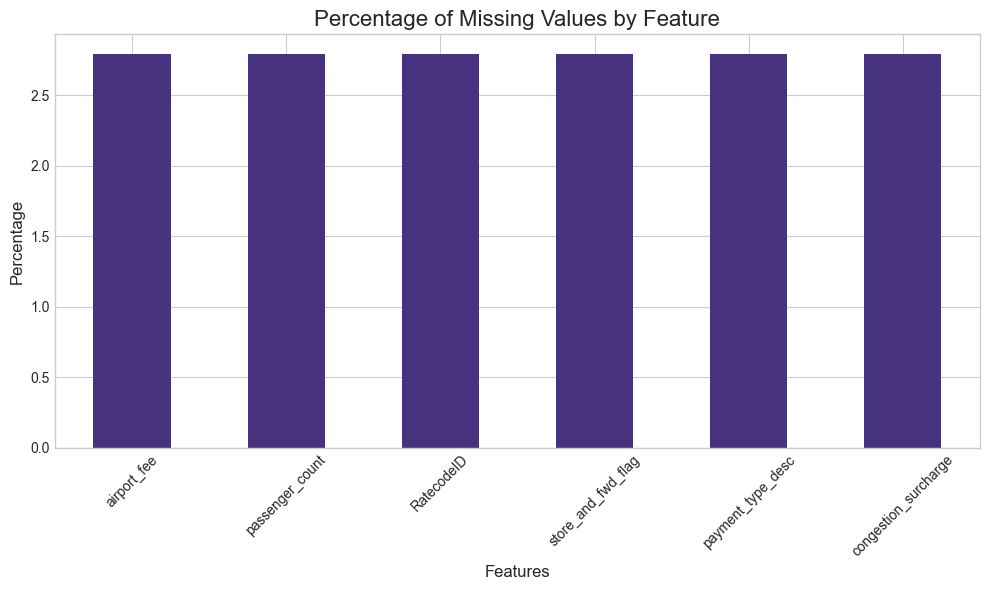

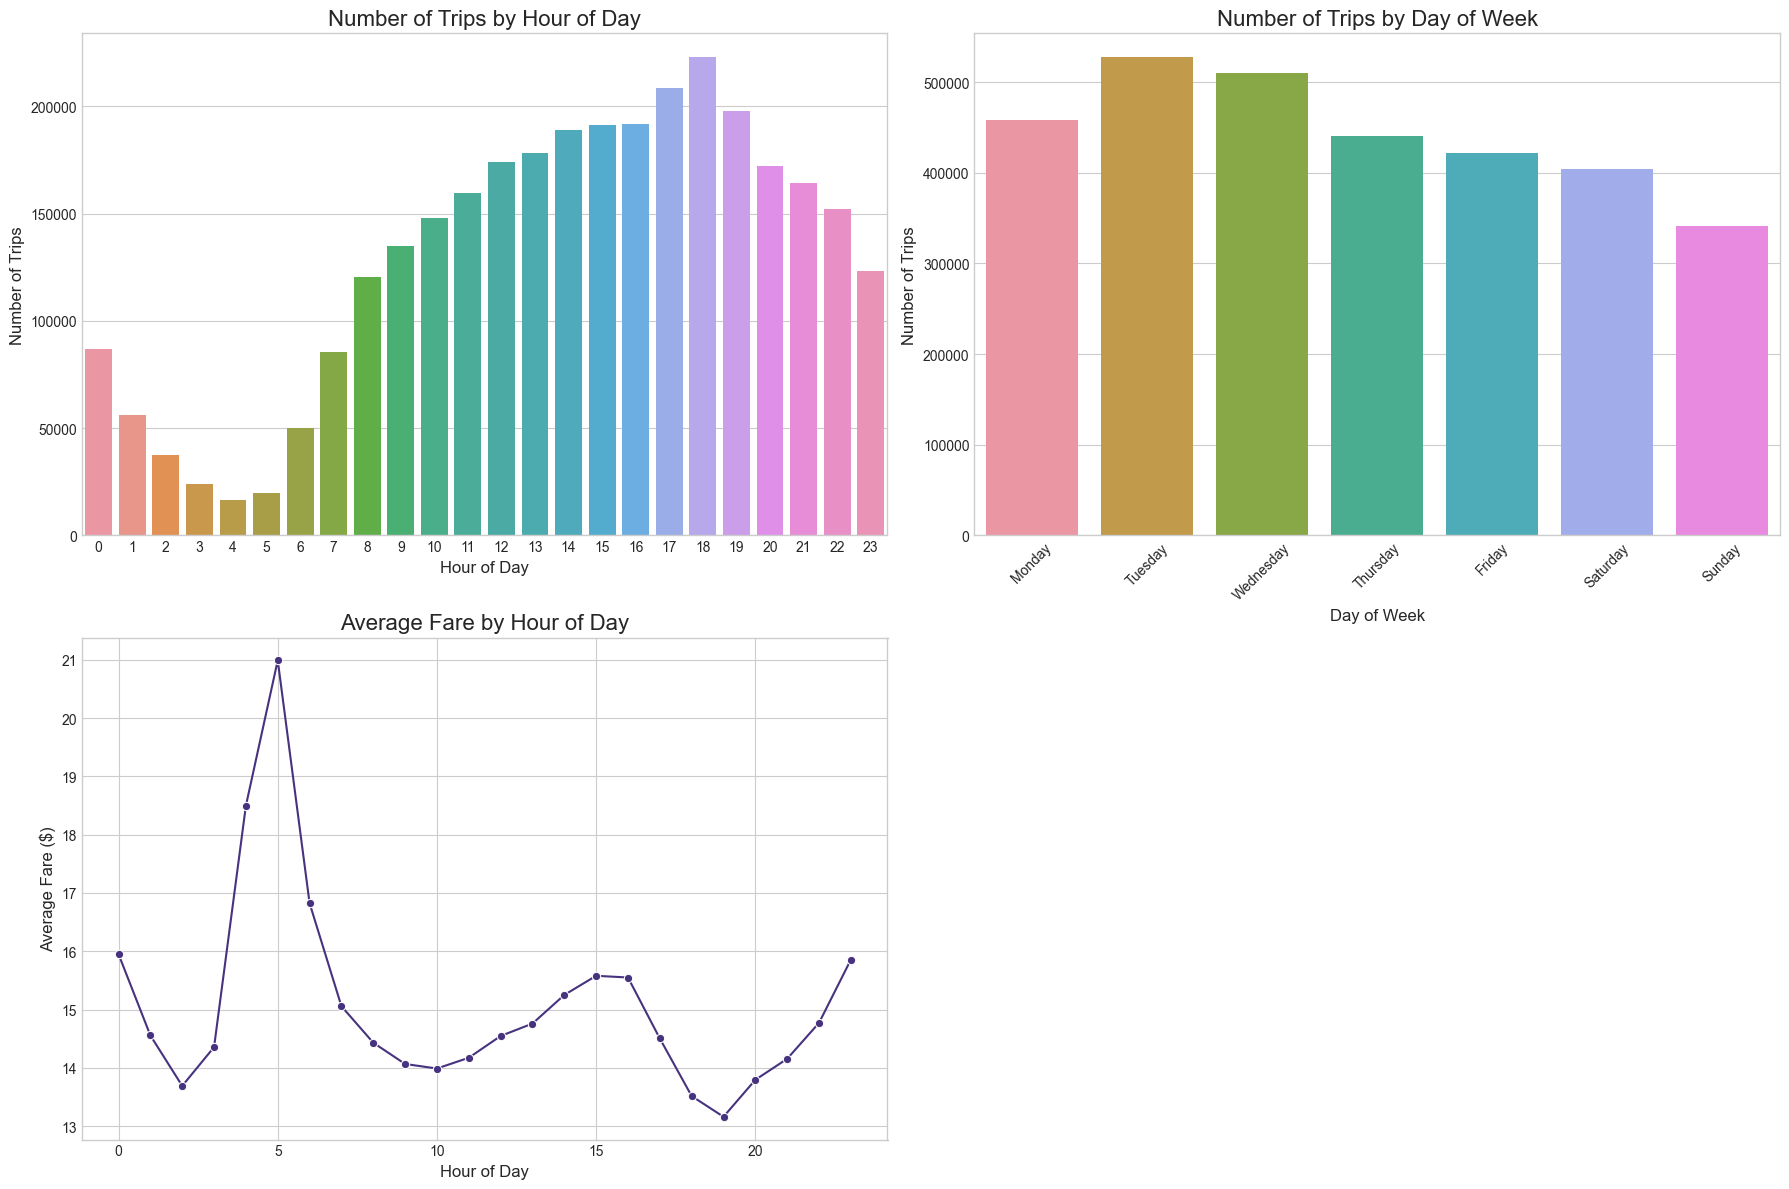

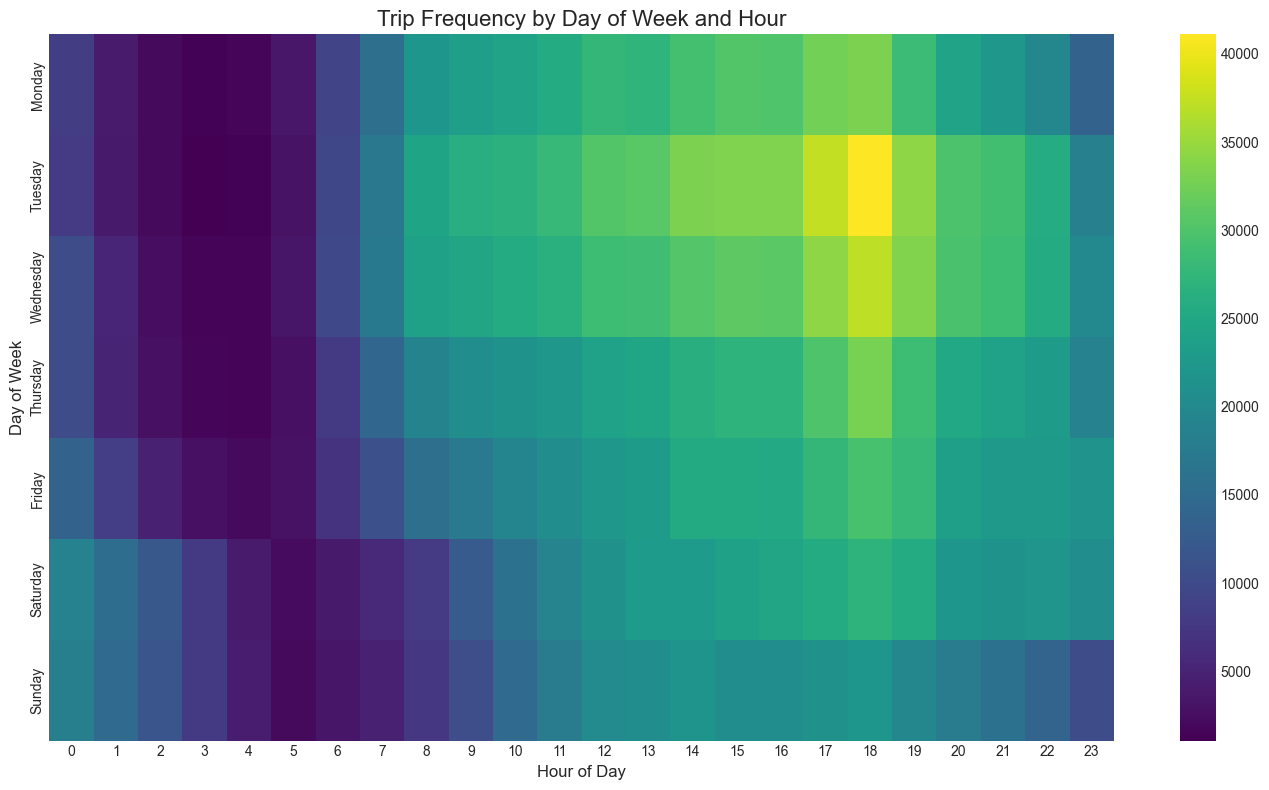

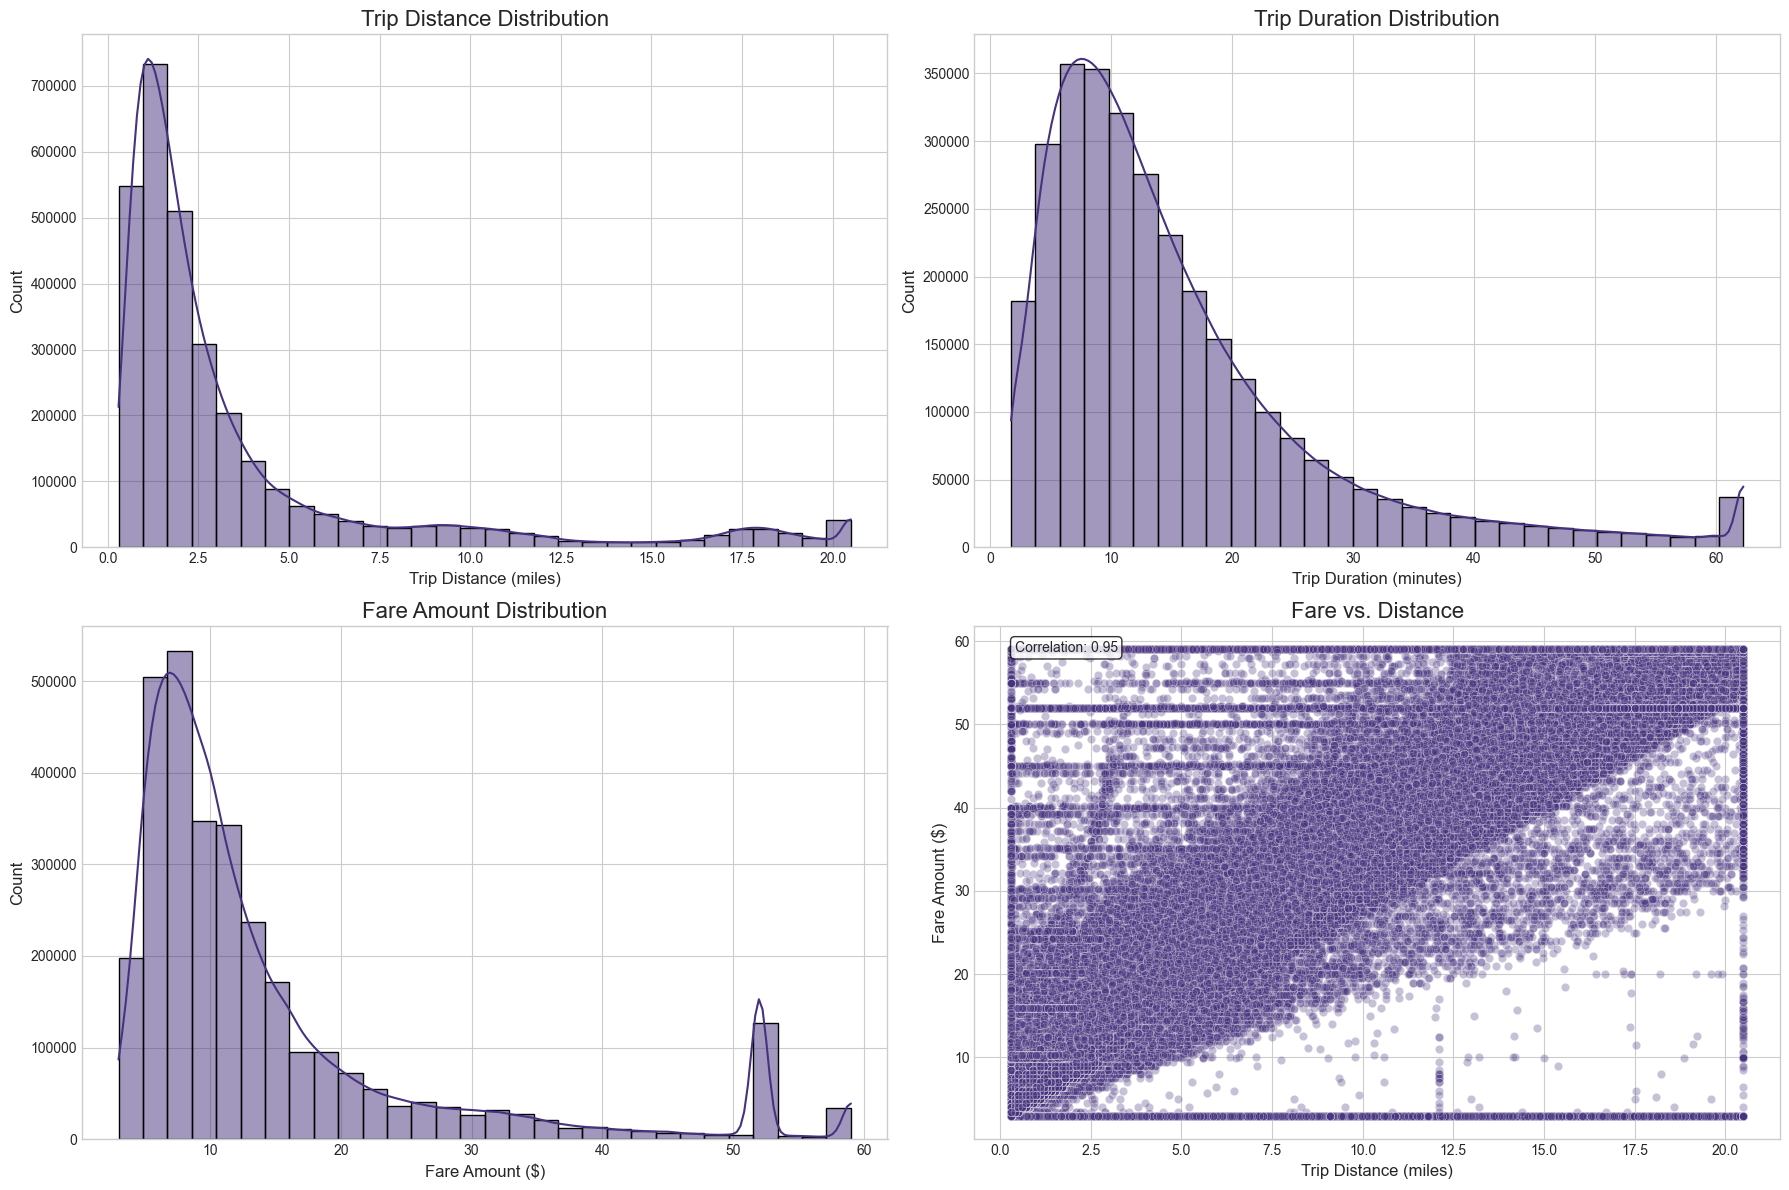

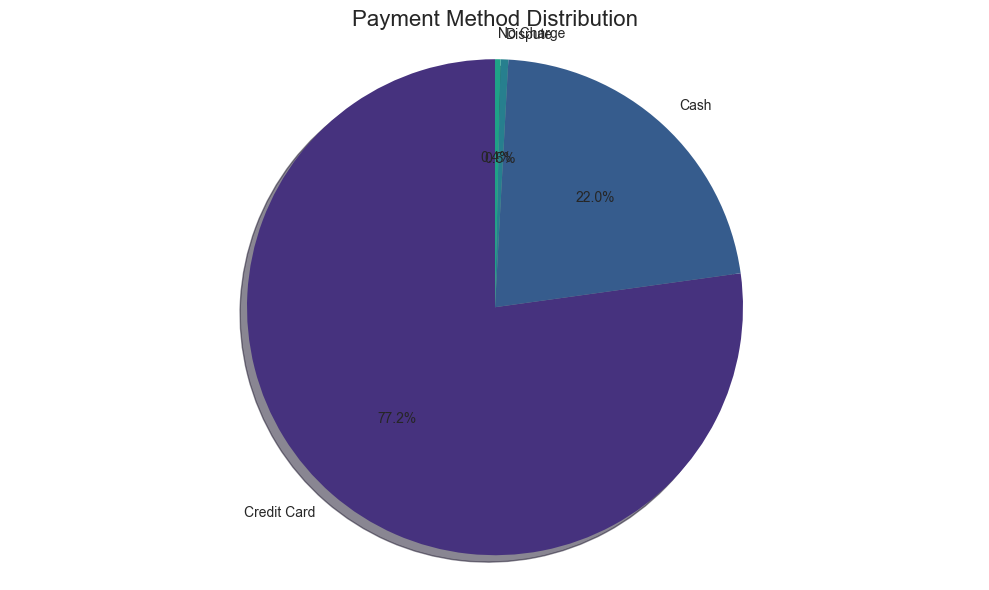

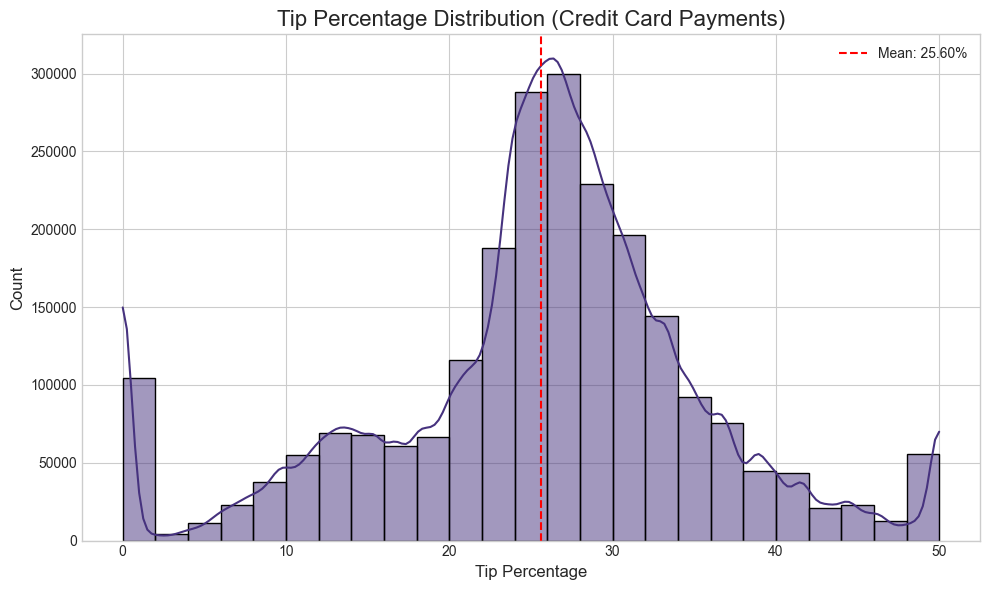

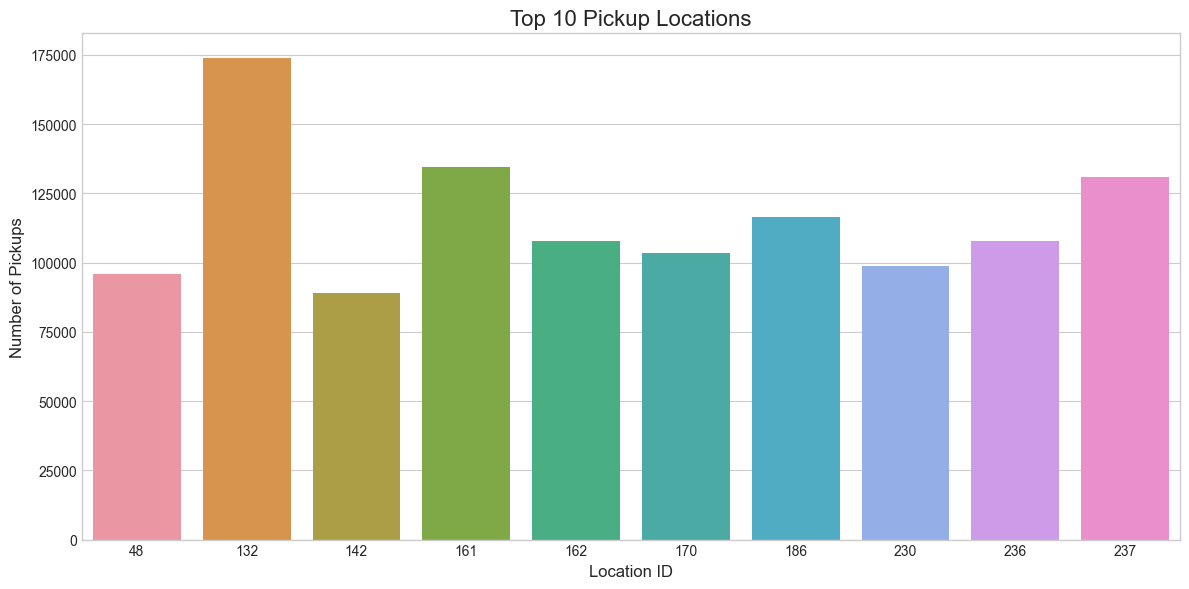

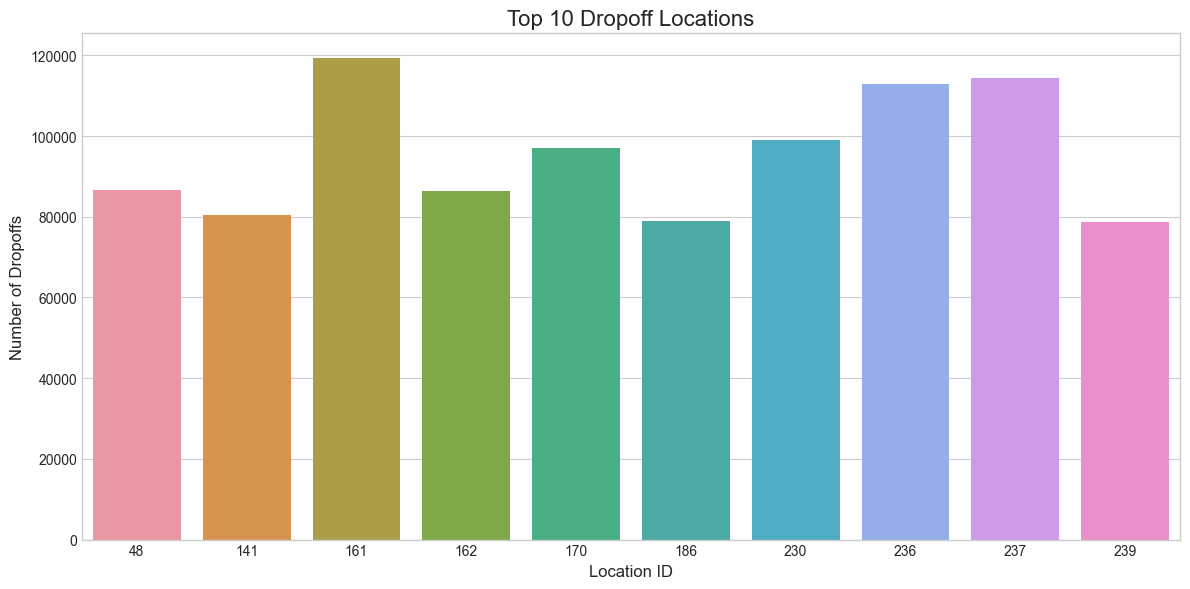

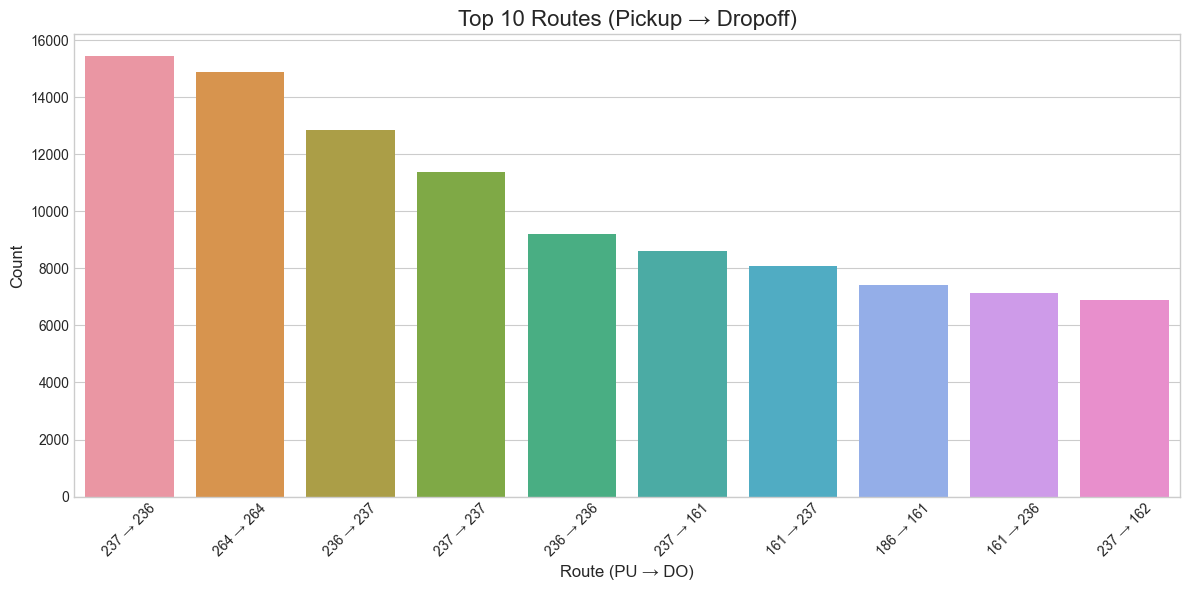

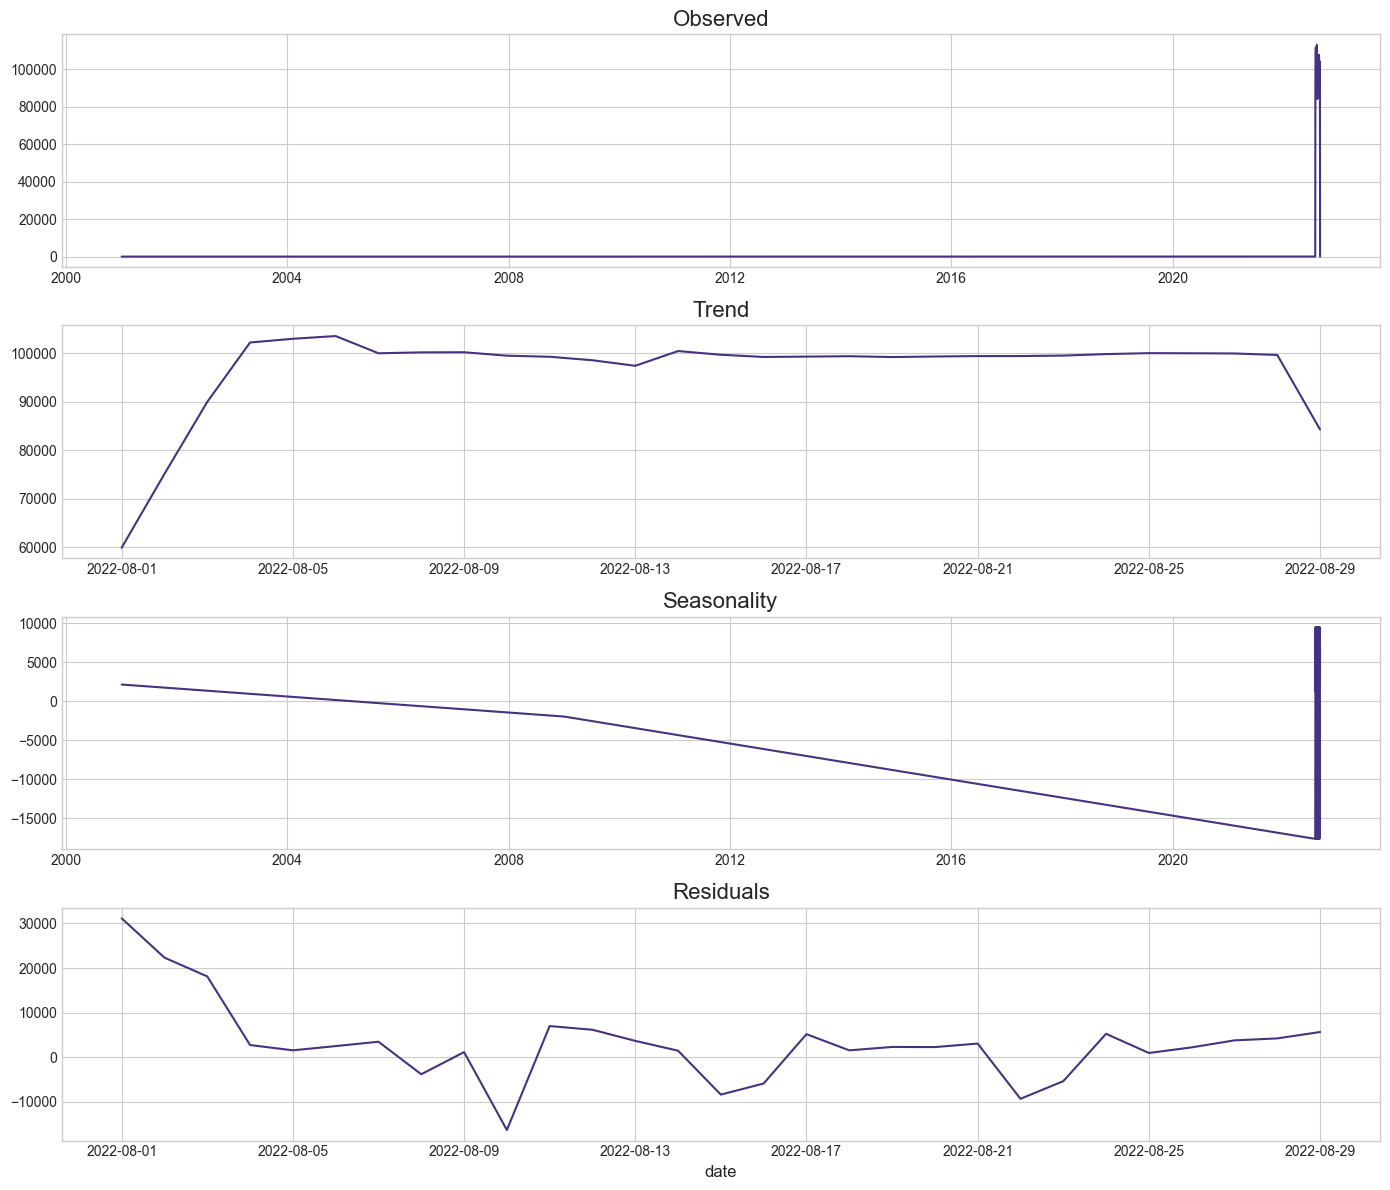

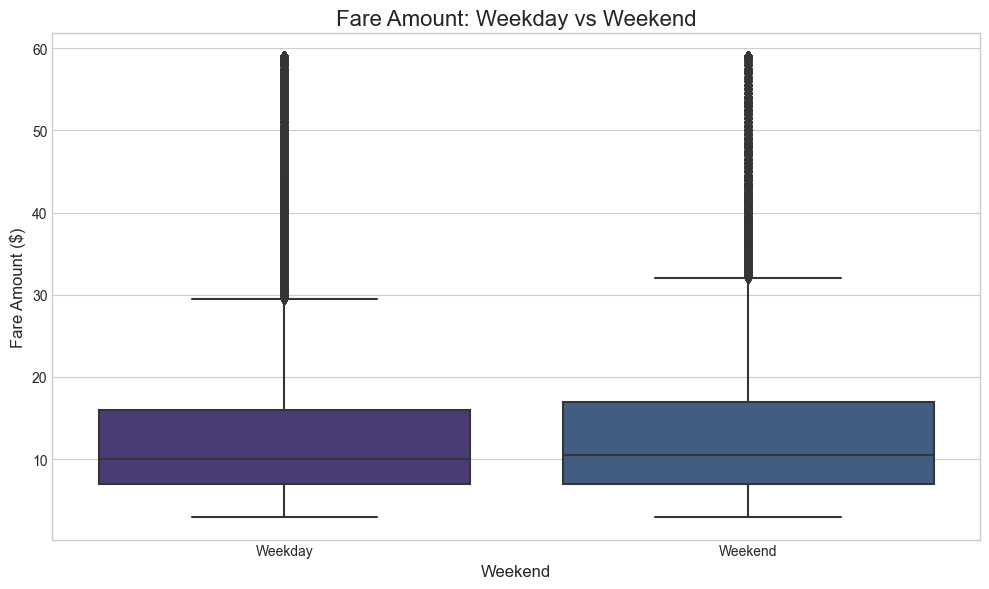

In [40]:
def analyze_locations(df):
    """
    Analyze pickup and dropoff locations
    """
    print("\n--- Location Analysis ---")
    
    # Top pickup locations
    top_pickup = df['PULocationID'].value_counts().head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_pickup.index, y=top_pickup.values)
    plt.title('Top 10 Pickup Locations')
    plt.xlabel('Location ID')
    plt.ylabel('Number of Pickups')
    plt.tight_layout()
    plt.savefig('top_pickup_locations.png')
    print("Top pickup locations saved as 'top_pickup_locations.png'")
    
    # Top dropoff locations
    top_dropoff = df['DOLocationID'].value_counts().head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_dropoff.index, y=top_dropoff.values)
    plt.title('Top 10 Dropoff Locations')
    plt.xlabel('Location ID')
    plt.ylabel('Number of Dropoffs')
    plt.tight_layout()
    plt.savefig('top_dropoff_locations.png')
    print("Top dropoff locations saved as 'top_dropoff_locations.png'")
    
    # Most common routes (pairs of pickup-dropoff)
    routes = df.groupby(['PULocationID', 'DOLocationID']).size().reset_index(name='count')
    top_routes = routes.sort_values('count', ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_routes.apply(lambda x: f"{x['PULocationID']} → {x['DOLocationID']}", axis=1),
                y=top_routes['count'])
    plt.title('Top 10 Routes (Pickup → Dropoff)')
    plt.xlabel('Route (PU → DO)')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('top_routes.png')
    print("Top routes saved as 'top_routes.png'")

def time_series_decomposition(df):
    """
    Perform time series decomposition to identify trends and seasonality
    """
    try:
        from statsmodels.tsa.seasonal import seasonal_decompose
        
        print("\n--- Time Series Decomposition ---")
        
        # Check if we have enough data points
        daily_trips = df.groupby('pickup_date').size()
        
        if len(daily_trips) >= 14:  # Need at least 2 weeks of data for meaningful decomposition
            # Convert to time series
            ts = daily_trips.reset_index()
            ts.columns = ['date', 'trips']
            ts.set_index('date', inplace=True)
            
            # Perform decomposition
            decomposition = seasonal_decompose(ts, model='additive', period=7)  # Assuming weekly seasonality
            
            # Plot decomposition
            fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12))
            
            decomposition.observed.plot(ax=ax1)
            ax1.set_title('Observed')
            ax1.set_xlabel('')
            
            decomposition.trend.plot(ax=ax2)
            ax2.set_title('Trend')
            ax2.set_xlabel('')
            
            decomposition.seasonal.plot(ax=ax3)
            ax3.set_title('Seasonality')
            ax3.set_xlabel('')
            
            decomposition.resid.plot(ax=ax4)
            ax4.set_title('Residuals')
            
            plt.tight_layout()
            plt.savefig('time_series_decomposition.png')
            print("Time series decomposition saved as 'time_series_decomposition.png'")
        else:
            print("Not enough data points for time series decomposition (need at least 14 days)")
    except Exception as e:
        print(f"Unable to perform time series decomposition: {e}")
        print("Make sure statsmodels is installed: pip install statsmodels")

def statistical_tests(df):
    """
    Perform statistical tests and analysis
    """
    print("\n--- Statistical Tests ---")
    
    # Check for normality in trip distance
    stat, p = stats.normaltest(df['trip_distance_filtered'])
    print(f"Trip Distance Normality Test: statistic={stat:.4f}, p-value={p:.4f}")
    if p < 0.05:
        print("Trip distance is not normally distributed")
    else:
        print("Trip distance appears to be normally distributed")
    
    # Weekday vs Weekend comparison
    df['is_weekend'] = df['pickup_dayofweek'].isin([5, 6])  # 5=Saturday, 6=Sunday
    
    # Compare fares: weekday vs weekend
    weekday_fares = df[~df['is_weekend']]['fare_amount_filtered']
    weekend_fares = df[df['is_weekend']]['fare_amount_filtered']
    
    # T-test for fare differences
    t_stat, p_val = stats.ttest_ind(weekday_fares, weekend_fares, equal_var=False)
    print(f"\nWeekday vs Weekend Fare T-Test: t={t_stat:.4f}, p-value={p_val:.4f}")
    if p_val < 0.05:
        print("There is a significant difference in fares between weekdays and weekends")
    else:
        print("No significant difference in fares between weekdays and weekends")
    
    print(f"Mean weekday fare: ${weekday_fares.mean():.2f}")
    print(f"Mean weekend fare: ${weekend_fares.mean():.2f}")
    
    # Plot the comparison
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='is_weekend', y='fare_amount_filtered', data=df)
    plt.title('Fare Amount: Weekday vs Weekend')
    plt.xlabel('Weekend')
    plt.xticks([0, 1], ['Weekday', 'Weekend'])
    plt.ylabel('Fare Amount ($)')
    plt.tight_layout()
    plt.savefig('weekday_weekend_comparison.png')
    print("Weekday vs weekend comparison saved as 'weekday_weekend_comparison.png'")

def create_summary_report(df):
    """
    Create a summary report with key statistics
    """
    print("\n--- Summary Statistics ---")
    
    # General statistics
    total_trips = len(df)
    total_revenue = df['total_amount'].sum()
    avg_fare = df['fare_amount'].mean()
    avg_distance = df['trip_distance'].mean()
    avg_duration = df['trip_duration'].mean() if 'trip_duration' in df.columns else float('nan')
    
    print(f"Total Trips: {total_trips:,}")
    print(f"Total Revenue: ${total_revenue:,.2f}")
    print(f"Average Fare: ${avg_fare:.2f}")
    print(f"Average Distance: {avg_distance:.2f} miles")
    if not np.isnan(avg_duration):
        print(f"Average Duration: {avg_duration:.2f} minutes")
    
    # Time patterns
    busiest_hour = df.groupby('pickup_hour').size().idxmax()
    busiest_day = df.groupby('pickup_day').size().idxmax()
    
    print(f"\nBusiest Hour: {busiest_hour}:00")
    print(f"Busiest Day: {busiest_day}")
    
    # Payment statistics
    card_payments = (df['payment_type'] == 1).sum()
    card_payment_pct = card_payments / total_trips * 100
    cash_payments = (df['payment_type'] == 2).sum()
    cash_payment_pct = cash_payments / total_trips * 100
    
    print(f"\nCredit Card Payments: {card_payments:,} ({card_payment_pct:.1f}%)")
    print(f"Cash Payments: {cash_payments:,} ({cash_payment_pct:.1f}%)")
    
    # Tip statistics (for credit card payments only)
    card_trips = df[df['payment_type'] == 1]
    avg_tip = card_trips['tip_amount'].mean()
    avg_tip_pct = card_trips['tip_percentage'].mean()
    
    print(f"\nAverage Tip (Credit Card): ${avg_tip:.2f}")
    print(f"Average Tip Percentage: {avg_tip_pct:.1f}%")
    
    # Missing data summary
    missing_data = df.isnull().sum()
    print("\nMissing Values Summary:")
    for col, count in missing_data[missing_data > 0].items():
        print(f"  {col}: {count:,} ({count/len(df)*100:.1f}%)")
    
    # Key correlations
    if 'trip_distance' in df.columns and 'fare_amount' in df.columns:
        fare_dist_corr = df['trip_distance'].corr(df['fare_amount'])
        print(f"\nFare-Distance Correlation: {fare_dist_corr:.3f}")
    
    if 'trip_duration' in df.columns and 'fare_amount' in df.columns:
        fare_time_corr = df['trip_duration'].corr(df['fare_amount'])
        print(f"Fare-Duration Correlation: {fare_time_corr:.3f}")

def perform_full_eda(file_path):
    """
    Perform full exploratory data analysis
    """
    # Load and prepare data
    df = load_and_prepare_data(file_path)
    
    # Analyze missing values
    analyze_missing_values(df)
    
    # Analyze time series patterns
    plot_time_series_patterns(df)
    
    # Analyze trip metrics
    analyze_trip_metrics(df)
    
    # Analyze locations
    analyze_locations(df)
    
    # Time series decomposition
    time_series_decomposition(df)
    
    # Statistical tests
    statistical_tests(df)
    
    # Create summary report
    create_summary_report(df)
    
    print("\nEDA completed! All visualizations have been saved as PNG files.")
    return df

# Example usage
if __name__ == "__main__":
    # Replace with your actual file path
    file_path = "taxi-dataset.parquet"
    
    # Run the full EDA
    df = perform_full_eda(file_path)
    
    # Display basic stats
    print("\n--- Basic Statistics ---")
    print(df.describe())

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

def detect_anomalies(df, file_path=None):
    """
    Main function to perform anomaly detection on taxi dataset
    
    Parameters:
    -----------
    df : pandas DataFrame
        Prepared taxi dataset
    file_path : str, optional
        Path to save output visualizations
        
    Returns:
    --------
    df_with_anomalies : pandas DataFrame
        Original dataframe with anomaly flags
    """
    print("\n=== ANOMALY DETECTION ANALYSIS ===")
    
    # Create a copy of the dataframe to work with
    df_copy = df.copy()
    
    # 1. Univariate anomaly detection (Z-score method)
    print("\n--- Univariate Anomaly Detection (Z-score method) ---")
    df_copy = detect_univariate_anomalies(df_copy)
    
    # 2. Multivariate anomaly detection (Isolation Forest)
    print("\n--- Multivariate Anomaly Detection (Isolation Forest) ---")
    df_copy = detect_multivariate_anomalies(df_copy)
    
    # 3. Time-series anomaly detection
    print("\n--- Time Series Anomaly Detection ---")
    df_copy = detect_time_series_anomalies(df_copy)
    
    # 4. Business rule-based anomalies
    print("\n--- Business Rule-Based Anomaly Detection ---")
    df_copy = detect_business_rule_anomalies(df_copy)
    
    # 5. Visualize anomalies
    visualize_anomalies(df_copy, file_path)
    
    # 6. Create summary report
    anomaly_summary_report(df_copy)
    
    return df_copy

def detect_univariate_anomalies(df, threshold=3.0):
    """
    Detect univariate anomalies using Z-score method
    
    Parameters:
    -----------
    df : pandas DataFrame
        Taxi dataset
    threshold : float
        Z-score threshold for anomaly detection (default: 3.0)
        
    Returns:
    --------
    df : pandas DataFrame
        DataFrame with anomaly flags
    """
    # Features to check for anomalies
    features = ['trip_distance', 'fare_amount', 'total_amount']
    if 'trip_duration' in df.columns:
        features.append('trip_duration')
    
    # Apply Z-score method to each feature
    for feature in features:
        # Skip if the feature doesn't exist
        if feature not in df.columns:
            continue
            
        col = f'{feature}_filtered' if f'{feature}_filtered' in df.columns else feature
        
        # Calculate Z-scores
        z_scores = stats.zscore(df[col])
        
        # Flag anomalies
        df[f'{feature}_zscore_anomaly'] = np.abs(z_scores) > threshold
        
        # Count anomalies
        anomaly_count = df[f'{feature}_zscore_anomaly'].sum()
        anomaly_pct = (anomaly_count / len(df)) * 100
        
        print(f"  {feature}: {anomaly_count} anomalies detected ({anomaly_pct:.2f}%)")
    
    # Create combined univariate anomaly flag
    df['univariate_anomaly'] = False
    for feature in features:
        if f'{feature}_zscore_anomaly' in df.columns:
            df['univariate_anomaly'] = df['univariate_anomaly'] | df[f'{feature}_zscore_anomaly']
    
    print(f"  Total univariate anomalies: {df['univariate_anomaly'].sum()} ({df['univariate_anomaly'].mean()*100:.2f}%)")
    
    return df

def detect_multivariate_anomalies(df, contamination=0.01):
    """
    Detect multivariate anomalies using Isolation Forest
    
    Parameters:
    -----------
    df : pandas DataFrame
        Taxi dataset
    contamination : float
        Expected proportion of anomalies (default: 0.01)
        
    Returns:
    --------
    df : pandas DataFrame
        DataFrame with anomaly flags
    """
    # Select numerical features for anomaly detection
    features = []
    for col in ['trip_distance_filtered', 'fare_amount_filtered', 'total_amount']:
        if col in df.columns:
            features.append(col)
            
    if 'trip_duration_filtered' in df.columns:
        features.append('trip_duration_filtered')
    
    # Skip if no features are available
    if not features:
        print("  No suitable features for multivariate anomaly detection")
        df['multivariate_anomaly'] = False
        return df
    
    # Extract features for anomaly detection
    X = df[features].fillna(df[features].mean())
    
    # Standardize the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Apply Isolation Forest
    model = IsolationForest(contamination=contamination, random_state=42)
    df['multivariate_anomaly'] = model.fit_predict(X_scaled) == -1
    
    # Count anomalies
    anomaly_count = df['multivariate_anomaly'].sum()
    anomaly_pct = (anomaly_count / len(df)) * 100
    
    print(f"  Using features: {', '.join(features)}")
    print(f"  Isolation Forest detected {anomaly_count} anomalies ({anomaly_pct:.2f}%)")
    
    # PCA for visualization (if we have at least 2 features)
    if len(features) >= 2:
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X_scaled)
        
        # Store PCA results for visualization
        df['pca_1'] = X_pca[:, 0]
        df['pca_2'] = X_pca[:, 1]
    
    return df

def detect_time_series_anomalies(df):
    """
    Detect anomalies in time series data
    
    Parameters:
    -----------
    df : pandas DataFrame
        Taxi dataset
        
    Returns:
    --------
    df : pandas DataFrame
        DataFrame with anomaly flags
    """
    # Check if we have datetime columns
    if 'tpep_pickup_datetime' not in df.columns:
        print("  No pickup datetime column found, skipping time series anomaly detection")
        df['time_series_anomaly'] = False
        return df
    
    # Aggregate by hour
    if 'pickup_hour' in df.columns and 'pickup_date' in df.columns:
        # Group by date and hour
        hourly_counts = df.groupby(['pickup_date', 'pickup_hour']).size().reset_index(name='trip_count')
        
        # Calculate average and std by hour across all days
        hour_stats = hourly_counts.groupby('pickup_hour')['trip_count'].agg(['mean', 'std']).reset_index()
        
        # Merge stats back to hourly counts
        hourly_counts = hourly_counts.merge(hour_stats, on='pickup_hour')
        
        # Calculate Z-scores
        hourly_counts['zscore'] = (hourly_counts['trip_count'] - hourly_counts['mean']) / hourly_counts['std'].replace(0, 1)
        
        # Flag anomalies
        hourly_counts['is_anomaly'] = abs(hourly_counts['zscore']) > 2.5
        
        # Store results
        hourly_anomalies = hourly_counts[hourly_counts['is_anomaly']]
        
        # Print results
        anomaly_count = len(hourly_anomalies)
        print(f"  Detected {anomaly_count} hourly time intervals with anomalous trip counts")
        
        if anomaly_count > 0:
            print("  Top anomalous time periods:")
            top_anomalies = hourly_anomalies.sort_values('zscore', key=abs, ascending=False).head(5)
            for _, row in top_anomalies.iterrows():
                direction = "high" if row['zscore'] > 0 else "low"
                print(f"    Date: {row['pickup_date']}, Hour: {row['pickup_hour']}:00 - {row['trip_count']} trips ({direction}, z-score: {row['zscore']:.2f})")
        
        # Create a flag for time series anomalies
        # Map the hourly anomalies back to the original dataframe
        df['time_series_anomaly'] = False
        
        for _, row in hourly_anomalies.iterrows():
            mask = (df['pickup_date'] == row['pickup_date']) & (df['pickup_hour'] == row['pickup_hour'])
            df.loc[mask, 'time_series_anomaly'] = True
    else:
        print("  Required columns for time series anomaly detection not found")
        df['time_series_anomaly'] = False
    
    return df

def detect_business_rule_anomalies(df):
    """
    Detect anomalies based on business rules
    
    Parameters:
    -----------
    df : pandas DataFrame
        Taxi dataset
        
    Returns:
    --------
    df : pandas DataFrame
        DataFrame with anomaly flags
    """
    # Initialize the anomaly flag
    df['business_rule_anomaly'] = False
    
    # Rule 1: Trips with very high fare relative to distance
    if 'fare_amount' in df.columns and 'trip_distance' in df.columns:
        # Calculate fare per mile
        df['fare_per_mile'] = np.where(
            df['trip_distance'] > 0,
            df['fare_amount'] / df['trip_distance'],
            0
        )
        
        # Get upper threshold (95th percentile)
        threshold = df[df['trip_distance'] > 1]['fare_per_mile'].quantile(0.95)
        
        # Flag anomalies
        df['high_fare_anomaly'] = (df['fare_per_mile'] > threshold) & (df['trip_distance'] > 1)
        df['business_rule_anomaly'] = df['business_rule_anomaly'] | df['high_fare_anomaly']
        
        # Count anomalies
        anomaly_count = df['high_fare_anomaly'].sum()
        print(f"  High fare per mile anomalies: {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")
    
    # Rule 2: Extremely slow trips (if we have duration data)
    if 'trip_duration' in df.columns and 'trip_distance' in df.columns:
        # Calculate speed in mph
        df['speed_mph'] = np.where(
            df['trip_duration'] > 0,
            df['trip_distance'] / (df['trip_duration'] / 60),
            0
        )
        
        # Flag extremely slow trips (less than 5 mph for trips over 1 mile)
        df['slow_trip_anomaly'] = (df['speed_mph'] < 5) & (df['speed_mph'] > 0) & (df['trip_distance'] > 1)
        df['business_rule_anomaly'] = df['business_rule_anomaly'] | df['slow_trip_anomaly']
        
        # Count anomalies
        anomaly_count = df['slow_trip_anomaly'].sum()
        print(f"  Extremely slow trip anomalies: {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")
    
    # Rule 3: Zero fare but non-zero distance
    if 'fare_amount' in df.columns and 'trip_distance' in df.columns:
        df['zero_fare_anomaly'] = (df['fare_amount'] == 0) & (df['trip_distance'] > 0.5)
        df['business_rule_anomaly'] = df['business_rule_anomaly'] | df['zero_fare_anomaly']
        
        # Count anomalies
        anomaly_count = df['zero_fare_anomaly'].sum()
        print(f"  Zero fare with non-zero distance anomalies: {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")
    
    # Rule 4: Unusual tip percentage (for credit card payments)
    if 'tip_percentage' in df.columns and 'payment_type' in df.columns:
        # Only consider credit card payments (payment_type = 1)
        high_tip = (df['payment_type'] == 1) & (df['tip_percentage'] > 30)
        df['high_tip_anomaly'] = high_tip
        df['business_rule_anomaly'] = df['business_rule_anomaly'] | df['high_tip_anomaly']
        
        # Count anomalies
        anomaly_count = df['high_tip_anomaly'].sum()
        print(f"  Unusually high tip percentage anomalies: {anomaly_count} ({anomaly_count/len(df)*100:.2f}%)")
    
    # Print total business rule anomalies
    total_anomalies = df['business_rule_anomaly'].sum()
    print(f"  Total business rule anomalies: {total_anomalies} ({total_anomalies/len(df)*100:.2f}%)")
    
    return df

def visualize_anomalies(df, file_path=None):
    """
    Visualize detected anomalies
    
    Parameters:
    -----------
    df : pandas DataFrame
        Taxi dataset with anomaly flags
    file_path : str, optional
        Path to save visualizations
    """
    print("\n--- Visualizing Anomalies ---")
    
    # Create figure for visualizations
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Scatter plot of fare vs. distance with anomalies
    if 'fare_amount_filtered' in df.columns and 'trip_distance_filtered' in df.columns:
        ax = axes[0, 0]
        
        # Plot normal points
        normal = ~df['univariate_anomaly'] & ~df['multivariate_anomaly']
        ax.scatter(df.loc[normal, 'trip_distance_filtered'], 
                   df.loc[normal, 'fare_amount_filtered'], 
                   alpha=0.1, color='blue', label='Normal')
        
        # Plot univariate anomalies
        uni_only = df['univariate_anomaly'] & ~df['multivariate_anomaly']
        ax.scatter(df.loc[uni_only, 'trip_distance_filtered'], 
                   df.loc[uni_only, 'fare_amount_filtered'], 
                   alpha=0.5, color='orange', label='Univariate Anomaly')
        
        # Plot multivariate anomalies
        multi = df['multivariate_anomaly']
        ax.scatter(df.loc[multi, 'trip_distance_filtered'], 
                   df.loc[multi, 'fare_amount_filtered'], 
                   alpha=0.5, color='red', label='Multivariate Anomaly')
        
        ax.set_title('Fare vs. Distance with Anomalies')
        ax.set_xlabel('Trip Distance (miles)')
        ax.set_ylabel('Fare Amount ($)')
        ax.legend()
    
    # 2. PCA visualization of multivariate anomalies
    if 'pca_1' in df.columns and 'pca_2' in df.columns:
        ax = axes[0, 1]
        
        # Plot normal points
        normal = ~df['multivariate_anomaly']
        ax.scatter(df.loc[normal, 'pca_1'], df.loc[normal, 'pca_2'], 
                   alpha=0.1, color='blue', label='Normal')
        
        # Plot anomalies
        anomalies = df['multivariate_anomaly']
        ax.scatter(df.loc[anomalies, 'pca_1'], df.loc[anomalies, 'pca_2'], 
                   alpha=0.5, color='red', label='Anomaly')
        
        ax.set_title('PCA Visualization of Multivariate Anomalies')
        ax.set_xlabel('PCA Component 1')
        ax.set_ylabel('PCA Component 2')
        ax.legend()
    
    # 3. Bar chart of anomaly counts by type
    ax = axes[1, 0]
    
    # Collect anomaly types and counts
    anomaly_types = []
    anomaly_counts = []
    
    for col in df.columns:
        if col.endswith('_anomaly') and col not in ['univariate_anomaly', 'multivariate_anomaly', 
                                                  'time_series_anomaly', 'business_rule_anomaly']:
            anomaly_types.append(col.replace('_anomaly', '').replace('_', ' ').title())
            anomaly_counts.append(df[col].sum())
    
    if anomaly_types:
        # Sort by count
        sorted_indices = np.argsort(anomaly_counts)[::-1]
        sorted_types = [anomaly_types[i] for i in sorted_indices]
        sorted_counts = [anomaly_counts[i] for i in sorted_indices]
        
        # Plot
        ax.bar(sorted_types, sorted_counts)
        ax.set_title('Anomaly Counts by Type')
        ax.set_xlabel('Anomaly Type')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)
        
        # Add count labels
        for i, count in enumerate(sorted_counts):
            ax.text(i, count + 5, str(count), ha='center')
    else:
        ax.text(0.5, 0.5, 'No specific anomaly types detected', 
                ha='center', va='center', transform=ax.transAxes)
    
    # 4. Time series anomalies (if available)
    ax = axes[1, 1]
    
    if 'pickup_date' in df.columns and 'pickup_hour' in df.columns:
        # Aggregate by date and hour
        hourly_counts = df.groupby(['pickup_date', 'pickup_hour']).size().reset_index(name='trip_count')
        hourly_anomalies = hourly_counts.merge(
            df.groupby(['pickup_date', 'pickup_hour'])['time_series_anomaly'].any().reset_index(),
            on=['pickup_date', 'pickup_hour']
        )
        
        # Sort by date and hour
        hourly_anomalies['datetime'] = pd.to_datetime(
            hourly_anomalies['pickup_date'].astype(str) + ' ' + 
            hourly_anomalies['pickup_hour'].astype(str) + ':00:00'
        )
        hourly_anomalies = hourly_anomalies.sort_values('datetime')
        
        # Plot time series
        ax.plot(hourly_anomalies['datetime'], hourly_anomalies['trip_count'], 
                color='blue', marker='.', alpha=0.5, label='Normal')
        
        # Highlight anomalies
        anomalies = hourly_anomalies[hourly_anomalies['time_series_anomaly']]
        if len(anomalies) > 0:
            ax.scatter(anomalies['datetime'], anomalies['trip_count'], 
                       color='red', s=50, label='Anomaly')
        
        ax.set_title('Trip Counts Over Time with Anomalies')
        ax.set_xlabel('Date and Hour')
        ax.set_ylabel('Trip Count')
        ax.tick_params(axis='x', rotation=45)
        if len(anomalies) > 0:
            ax.legend()
    else:
        ax.text(0.5, 0.5, 'Time series data not available', 
                ha='center', va='center', transform=ax.transAxes)
    
    plt.tight_layout()
    
    # Save figure if file_path is provided
    if file_path:
        plt.savefig(f"{file_path}/anomaly_detection_summary.png")
        print(f"  Anomaly visualizations saved to {file_path}/anomaly_detection_summary.png")
    
    # Create additional visualizations
    
    # 1. Business rule anomalies
    if 'business_rule_anomaly' in df.columns:
        plt.figure(figsize=(12, 8))
        
        # Plot fare per mile distribution
        if 'fare_per_mile' in df.columns:
            plt.figure(figsize=(12, 6))
            
            # Plot normal trips
            sns.histplot(df.loc[~df['high_fare_anomaly'], 'fare_per_mile'].clip(0, 20), 
                         color='blue', label='Normal', bins=50, alpha=0.5)
            
            # Plot anomalies
            if df['high_fare_anomaly'].sum() > 0:
                sns.histplot(df.loc[df['high_fare_anomaly'], 'fare_per_mile'].clip(0, 20), 
                             color='red', label='Anomaly', bins=50, alpha=0.5)
            
            plt.title('Fare per Mile Distribution with Anomalies')
            plt.xlabel('Fare per Mile ($)')
            plt.ylabel('Count')
            plt.legend()
            
            if file_path:
                plt.savefig(f"{file_path}/fare_per_mile_anomalies.png")
                print(f"  Fare per mile visualization saved to {file_path}/fare_per_mile_anomalies.png")
        
        # Plot speed distribution
        if 'speed_mph' in df.columns:
            plt.figure(figsize=(12, 6))
            
            # Plot normal trips
            sns.histplot(df.loc[~df['slow_trip_anomaly'], 'speed_mph'].clip(0, 50), 
                         color='blue', label='Normal', bins=50, alpha=0.5)
            
            # Plot anomalies
            if df['slow_trip_anomaly'].sum() > 0:
                sns.histplot(df.loc[df['slow_trip_anomaly'], 'speed_mph'].clip(0, 50), 
                             color='red', label='Anomaly', bins=50, alpha=0.5)
            
            plt.title('Trip Speed Distribution with Anomalies')
            plt.xlabel('Speed (mph)')
            plt.ylabel('Count')
            plt.legend()
            
            if file_path:
                plt.savefig(f"{file_path}/speed_anomalies.png")
                print(f"  Speed visualization saved to {file_path}/speed_anomalies.png")
    
    # Close plots
    plt.close('all')

def anomaly_summary_report(df):
    """
    Create a summary report of detected anomalies
    
    Parameters:
    -----------
    df : pandas DataFrame
        Taxi dataset with anomaly flags
    """
    print("\n--- Anomaly Detection Summary Report ---")
    
    # Calculate total anomalies
    df['any_anomaly'] = (df['univariate_anomaly'] | 
                         df['multivariate_anomaly'] | 
                         df['time_series_anomaly'] | 
                         df['business_rule_anomaly'])
    
    # Print overall statistics
    total_trips = len(df)
    total_anomalies = df['any_anomaly'].sum()
    anomaly_pct = (total_anomalies / total_trips) * 100
    
    print(f"Total trips analyzed: {total_trips:,}")
    print(f"Total anomalies detected: {total_anomalies:,} ({anomaly_pct:.2f}%)")
    
    # Print anomalies by type
    print("\nAnomalies by detection method:")
    print(f"  Univariate anomalies (Z-score): {df['univariate_anomaly'].sum():,} ({df['univariate_anomaly'].mean()*100:.2f}%)")
    print(f"  Multivariate anomalies (Isolation Forest): {df['multivariate_anomaly'].sum():,} ({df['multivariate_anomaly'].mean()*100:.2f}%)")
    print(f"  Time series anomalies: {df['time_series_anomaly'].sum():,} ({df['time_series_anomaly'].mean()*100:.2f}%)")
    print(f"  Business rule anomalies: {df['business_rule_anomaly'].sum():,} ({df['business_rule_anomaly'].mean()*100:.2f}%)")
    
    # Print specific anomaly types
    print("\nSpecific anomaly types:")
    
    for col in sorted(df.columns):
        if col.endswith('_anomaly') and col not in ['univariate_anomaly', 'multivariate_anomaly', 
                                                  'time_series_anomaly', 'business_rule_anomaly', 'any_anomaly']:
            name = col.replace('_anomaly', '').replace('_', ' ').title()
            count = df[col].sum()
            pct = (count / total_trips) * 100
            print(f"  {name}: {count:,} ({pct:.2f}%)")
    
    # Print overlap statistics
    print("\nOverlap between detection methods:")
    
    if 'univariate_anomaly' in df.columns and 'multivariate_anomaly' in df.columns:
        overlap = (df['univariate_anomaly'] & df['multivariate_anomaly']).sum()
        pct_of_uni = (overlap / df['univariate_anomaly'].sum()) * 100 if df['univariate_anomaly'].sum() > 0 else 0
        pct_of_multi = (overlap / df['multivariate_anomaly'].sum()) * 100 if df['multivariate_anomaly'].sum() > 0 else 0
        print(f"  Univariate + Multivariate: {overlap:,} ({pct_of_uni:.2f}% of univariate, {pct_of_multi:.2f}% of multivariate)")
    
    # Impact on key business metrics
    print("\nImpact of anomalies on key metrics:")
    
    if 'fare_amount' in df.columns:
        anomaly_fare = df.loc[df['any_anomaly'], 'fare_amount'].sum()
        normal_fare = df.loc[~df['any_anomaly'], 'fare_amount'].sum()
        total_fare = df['fare_amount'].sum()
        
        anomaly_fare_pct = (anomaly_fare / total_fare) * 100
        
        print(f"  Anomalies represent {anomaly_pct:.2f}% of trips but {anomaly_fare_pct:.2f}% of total fare amount")
        
        avg_anomaly_fare = df.loc[df['any_anomaly'], 'fare_amount'].mean()
        avg_normal_fare = df.loc[~df['any_anomaly'], 'fare_amount'].mean()
        
        print(f"  Average fare for anomalous trips: ${avg_anomaly_fare:.2f}")
        print(f"  Average fare for normal trips: ${avg_normal_fare:.2f}")
    
    # Most common anomaly patterns
    print("\nMost common anomaly patterns:")
    
    # Create pattern column
    pattern_cols = [col for col in df.columns if col.endswith('_anomaly') and col != 'any_anomaly']
    
    if pattern_cols:
        # Convert boolean columns to string representation
        patterns = df[pattern_cols].apply(lambda row: ''.join(['1' if val else '0' for val in row]), axis=1)
        
        # Count patterns
        pattern_counts = patterns.value_counts().head(5)
        
        # Print most common patterns
        for pattern, count in pattern_counts.items():
            if pattern != '0' * len(pattern_cols):  # Skip the all-zero pattern
                pct = (count / df['any_anomaly'].sum()) * 100
                
                # Create readable description
                description = []
                for i, col in enumerate(pattern_cols):
                    if pattern[i] == '1':
                        name = col.replace('_anomaly', '').replace('_', ' ').title()
                        description.append(name)
                
                if description:
                    print(f"  {' + '.join(description)}: {count:,} ({pct:.2f}%)")
    
    # Recommendations based on anomalies
    print("\nRecommendations based on anomaly analysis:")
    
    if 'high_fare_anomaly' in df.columns and df['high_fare_anomaly'].sum() > 0:
        print("  1. Investigate trips with unusually high fare per mile ratio")
    
    if 'slow_trip_anomaly' in df.columns and df['slow_trip_anomaly'].sum() > 0:
        print("  2. Review extremely slow trips which may indicate traffic issues or meter problems")
    
    if 'zero_fare_anomaly' in df.columns and df['zero_fare_anomaly'].sum() > 0:
        print("  3. Investigate trips with zero fare but non-zero distance")
    
    if 'high_tip_anomaly' in df.columns and df['high_tip_anomaly'].sum() > 0:
        print("  4. Review unusually high tip percentages which may indicate data entry errors")
    
    if 'time_series_anomaly' in df.columns and df['time_series_anomaly'].sum() > 0:
        print("  5. Analyze time periods with abnormal trip volumes to understand demand patterns")

# Update the main EDA function to include anomaly detection
# Update the main EDA function to include anomaly detection
def perform_full_eda_with_anomaly_detection(file_path):
    """
    Perform full exploratory data analysis with anomaly detection
    """
    # Load and prepare data
    df = load_and_prepare_data(file_path)
    
    # Perform standard EDA
    analyze_missing_values(df)
    plot_time_series_patterns(df)
    analyze_trip_metrics(df)
    analyze_locations(df)
    time_series_decomposition(df)
    statistical_tests(df)
    create_summary_report(df)
    
    # Perform anomaly detection
    df_with_anomalies = detect_anomalies(df, file_path)
    
    print("\nEDA and Anomaly Detection completed! All visualizations have been saved as PNG files.")
    return df_with_anomalies

# Example of how to use with Prophet for time series forecasting and anomaly detection
def forecast_with_prophet(df, target_column='trip_count', period_freq='H', periods_to_forecast=24):
    """
    Forecast time series data using Prophet and detect anomalies
    
    Parameters:
    -----------
    df : pandas DataFrame
        Prepared taxi dataset
    target_column : str
        Column to forecast (default: 'trip_count')
    period_freq : str
        Frequency of time periods ('H' for hourly, 'D' for daily)
    periods_to_forecast : int
        Number of periods to forecast ahead
        
    Returns:
    --------
    forecast : pandas DataFrame
        Prophet forecast results
    """
    try:
        from prophet import Prophet
        
        print("\n--- Time Series Forecasting with Prophet ---")
        
        # Prepare data for Prophet
        if period_freq == 'H':
            # Hourly data
            time_series = df.groupby(['pickup_date', 'pickup_hour']).size().reset_index(name=target_column)
            time_series['ds'] = pd.to_datetime(
                time_series['pickup_date'].astype(str) + ' ' + 
                time_series['pickup_hour'].astype(str) + ':00:00'
            )
        else:
            # Daily data
            time_series = df.groupby('pickup_date').size().reset_index(name=target_column)
            time_series['ds'] = pd.to_datetime(time_series['pickup_date'])
        
        # Prepare DataFrame for Prophet
        prophet_df = time_series[['ds', target_column]].rename(columns={target_column: 'y'})
        
        # Train Prophet model
        model = Prophet(
            interval_width=0.95,
            daily_seasonality=True if period_freq == 'H' else False,
            weekly_seasonality=True,
            yearly_seasonality=False,
            seasonality_mode='additive'
        )
        
        # Add hourly seasonality if using hourly data
        if period_freq == 'H':
            model.add_seasonality(name='hourly', period=24, fourier_order=5)
        
        # Fit model
        model.fit(prophet_df)
        
        # Create future dataframe
        future = model.make_future_dataframe(
            periods=periods_to_forecast,
            freq=period_freq
        )
        
        # Generate forecast
        forecast = model.predict(future)
        
        # Plot forecast
        fig = model.plot(forecast)
        plt.title(f'Prophet Forecast for {target_column}')
        plt.xlabel('Date')
        plt.ylabel(target_column)
        plt.tight_layout()
        plt.savefig(f'prophet_forecast_{target_column}.png')
        print(f"  Prophet forecast saved as 'prophet_forecast_{target_column}.png'")
        
        # Plot components
        fig = model.plot_components(forecast)
        plt.tight_layout()
        plt.savefig(f'prophet_components_{target_column}.png')
        print(f"  Prophet components saved as 'prophet_components_{target_column}.png'")
        
        # Detect anomalies
        # Merge actual values with forecasted values
        actual_vs_predicted = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].merge(
            prophet_df, on='ds', how='inner'
        )
        
        # Flag anomalies
        actual_vs_predicted['anomaly'] = (actual_vs_predicted['y'] < actual_vs_predicted['yhat_lower']) | \
                                         (actual_vs_predicted['y'] > actual_vs_predicted['yhat_upper'])
        
        # Count anomalies
        anomaly_count = actual_vs_predicted['anomaly'].sum()
        anomaly_pct = (anomaly_count / len(actual_vs_predicted)) * 100
        
        print(f"  Prophet detected {anomaly_count} anomalies ({anomaly_pct:.2f}%)")
        
        # Plot anomalies
        plt.figure(figsize=(12, 6))
        
        # Plot prediction intervals
        plt.fill_between(
            actual_vs_predicted['ds'], 
            actual_vs_predicted['yhat_lower'], 
            actual_vs_predicted['yhat_upper'], 
            color='lightgray', alpha=0.5,
            label='95% Prediction Interval'
        )
        
        # Plot predicted values
        plt.plot(
            actual_vs_predicted['ds'], 
            actual_vs_predicted['yhat'], 
            color='blue', linestyle='--',
            label='Predicted'
        )
        
        # Plot actual values
        plt.plot(
            actual_vs_predicted['ds'], 
            actual_vs_predicted['y'], 
            color='green', marker='.',
            label='Actual'
        )
        
        # Plot anomalies
        anomalies = actual_vs_predicted[actual_vs_predicted['anomaly']]
        plt.scatter(
            anomalies['ds'], 
            anomalies['y'], 
            color='red', s=50,
            label='Anomaly'
        )
        
        plt.title(f'Prophet Anomaly Detection for {target_column}')
        plt.xlabel('Date')
        plt.ylabel(target_column)
        plt.legend()
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.savefig(f'prophet_anomalies_{target_column}.png')
        print(f"  Prophet anomalies visualization saved as 'prophet_anomalies_{target_column}.png'")
        
        return forecast, actual_vs_predicted
    
    except ImportError:
        print("Prophet not installed. Install with: pip install prophet")
        return None


=== TAXI DATASET ANALYSIS WITH ANOMALY DETECTION ===

Starting analysis...
Loading data...

Dataset Shape: (3152677, 19)

Columns with missing values:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          93174
trip_distance                0
RatecodeID               93174
store_and_fwd_flag       93174
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     93174
airport_fee              93174
dtype: int64

--- Missing Values Analysis ---
                      Total   Percent
airport_fee           86672  2.792474
passenger_count       86672  2.792474
RatecodeID            86672  2.792474
store_and_fwd_flag    86672  2.792474
payment_type_desc     86

NotADirectoryError: [Errno 20] Not a directory: '/Users/tanmay/Documents/GitHub/baby-driver/taxi-dataset.parquet/anomaly_detection_summary.png'

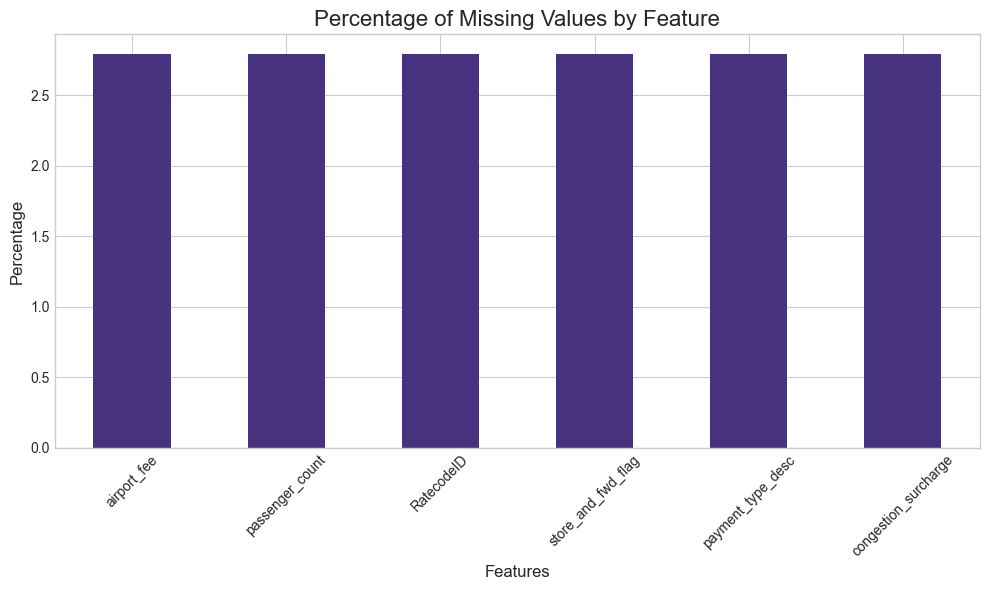

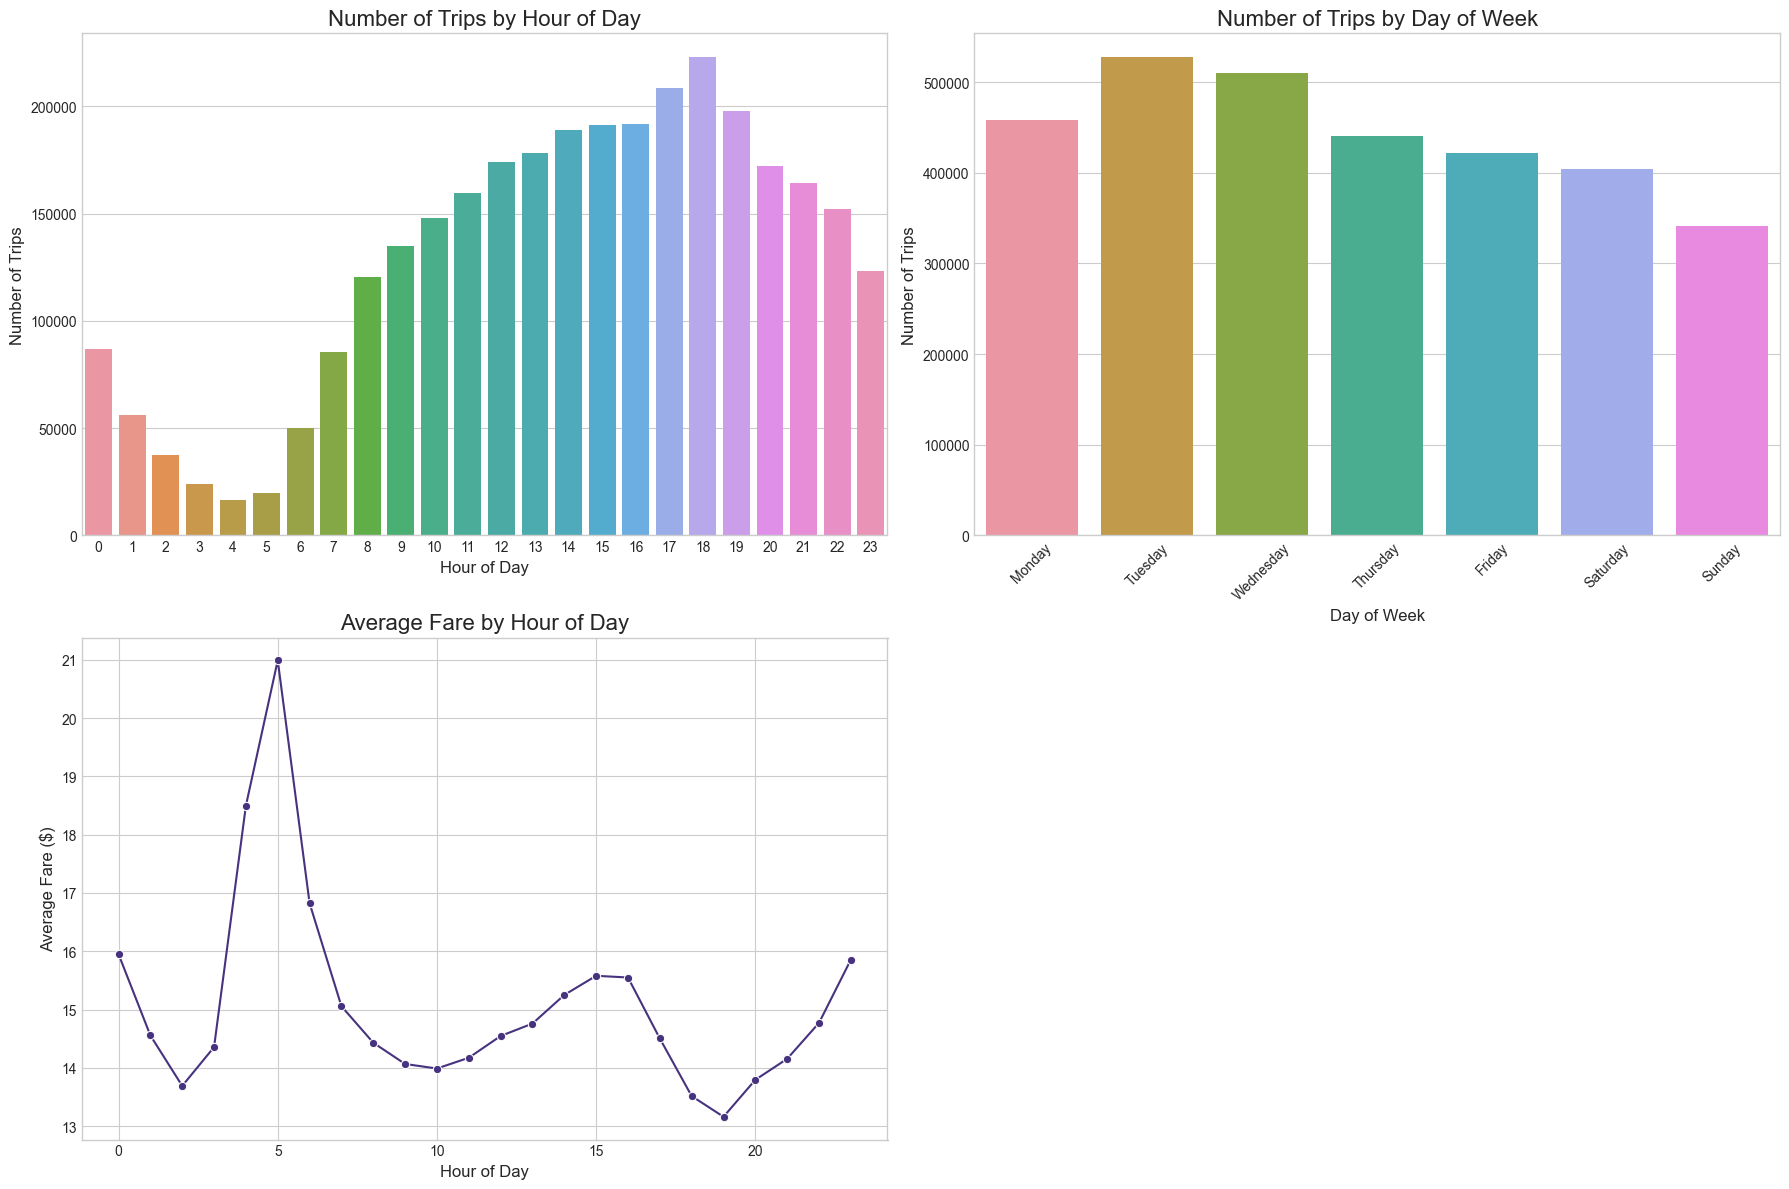

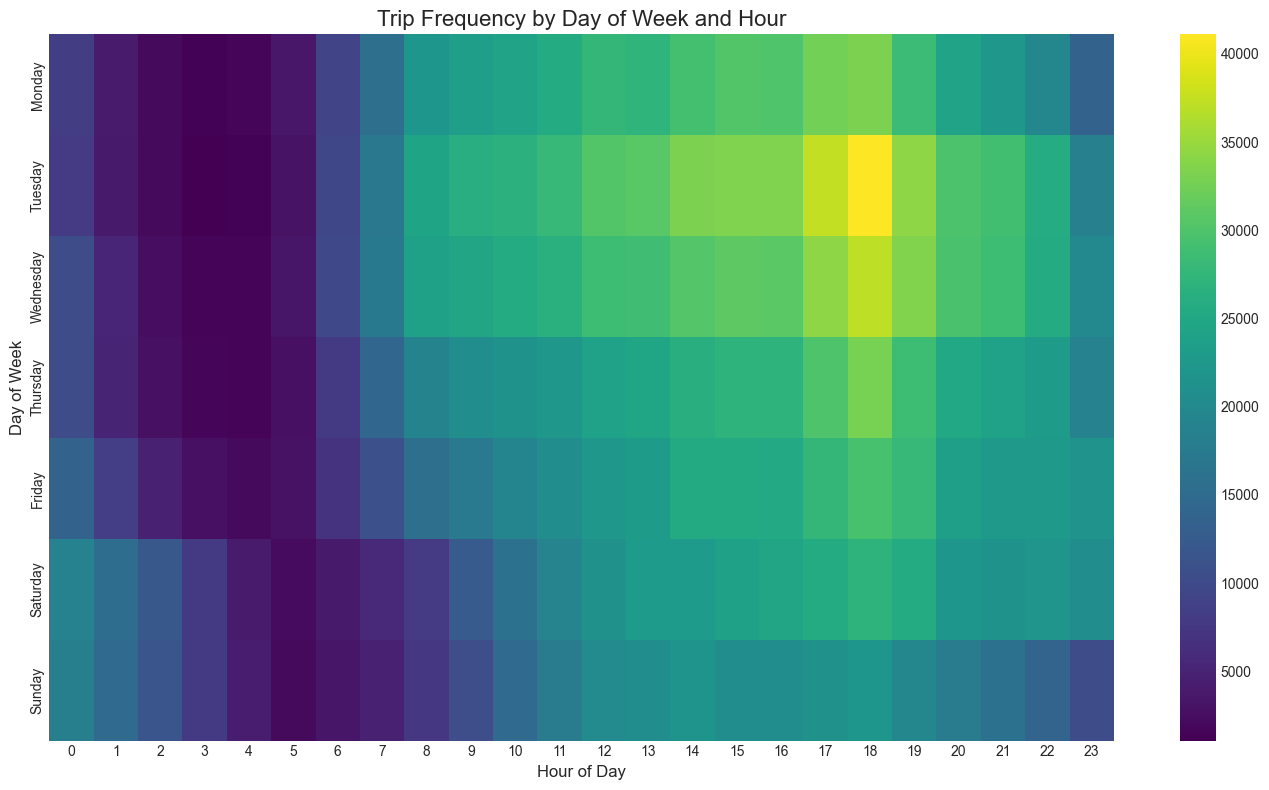

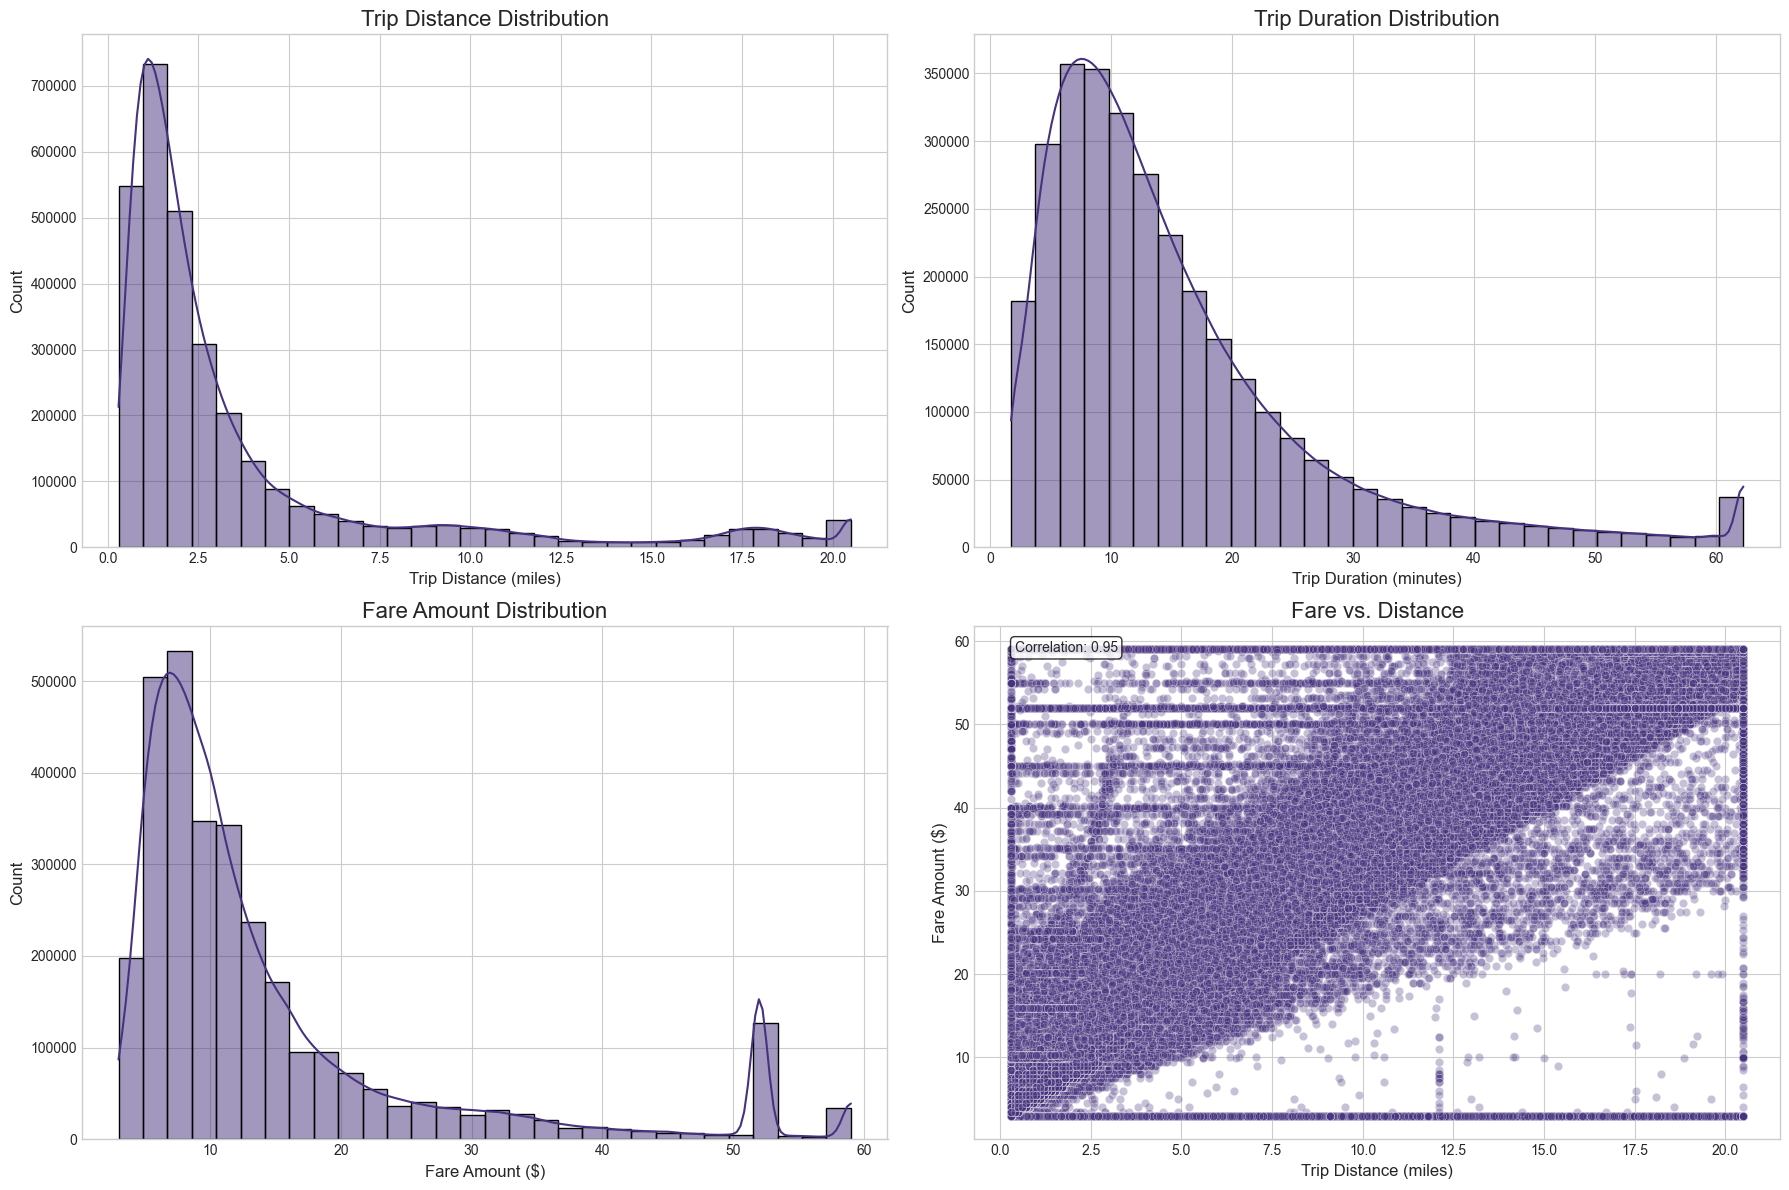

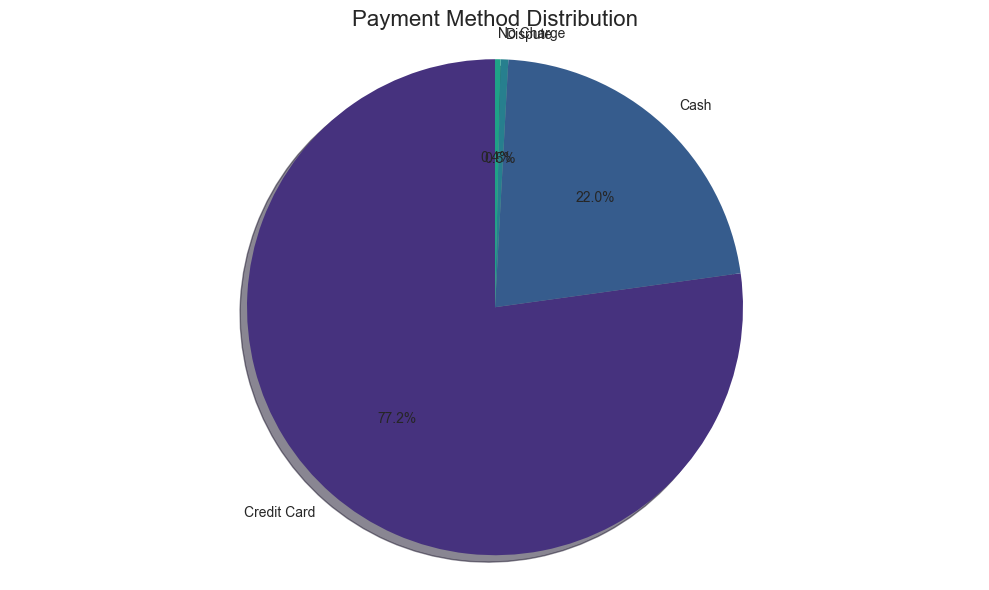

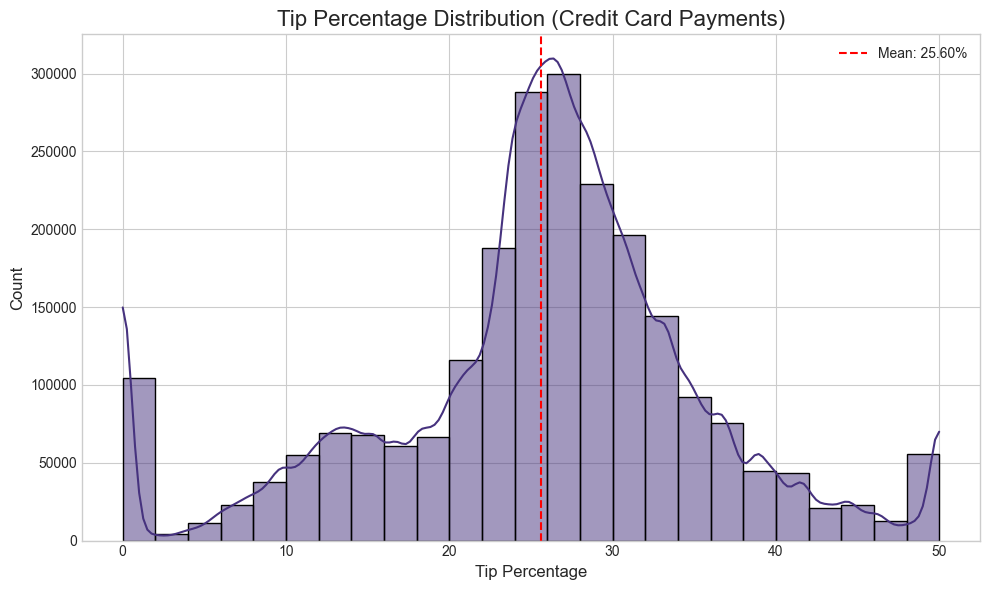

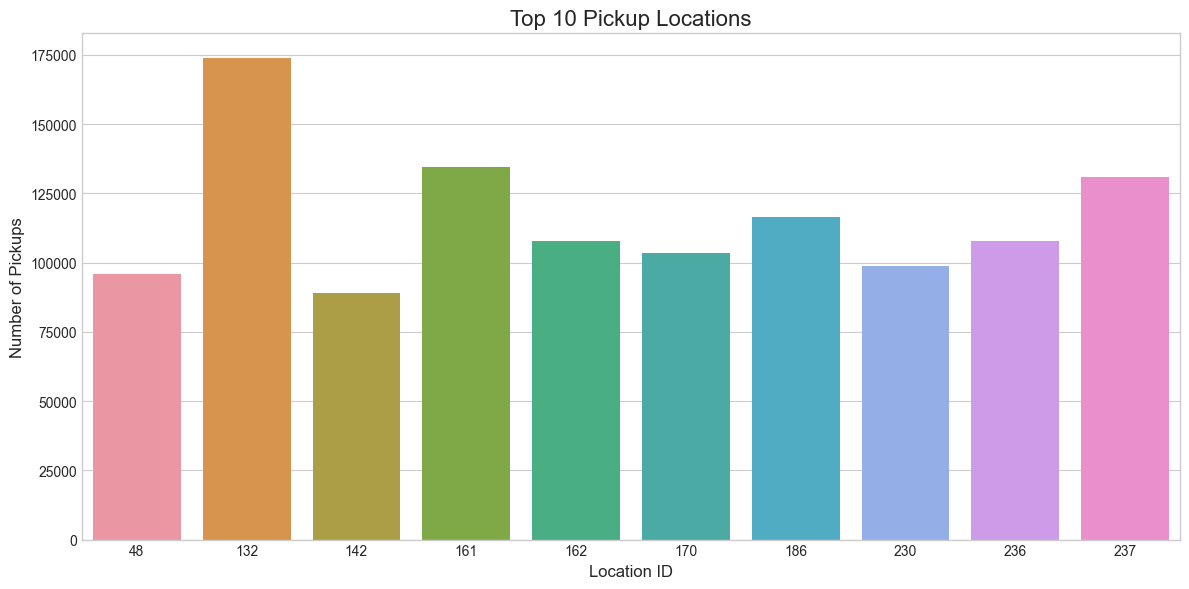

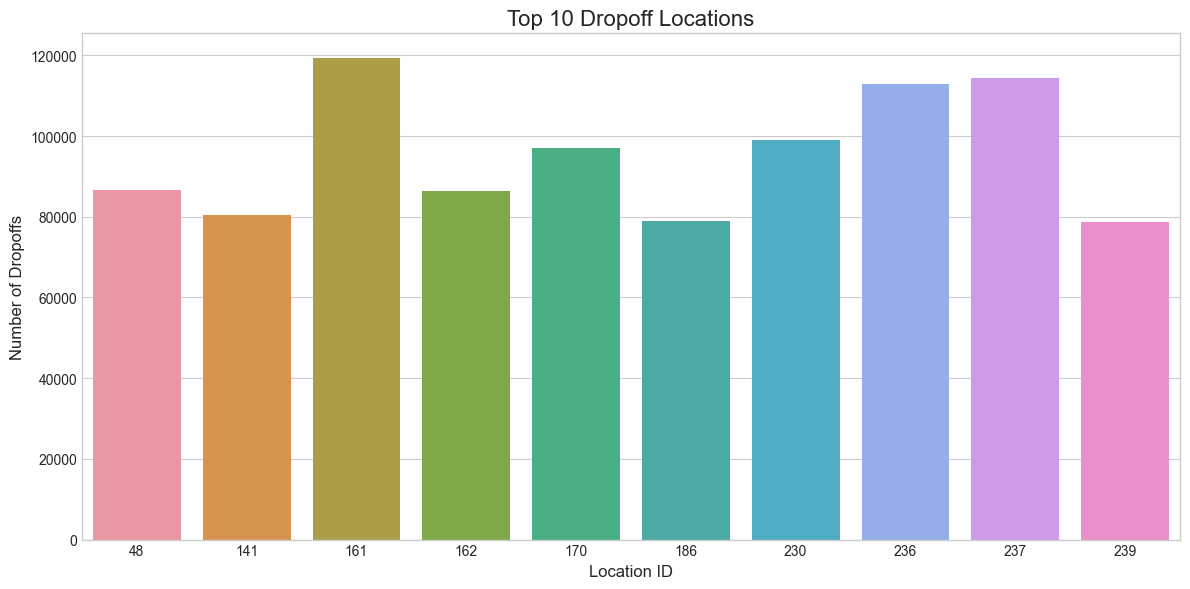

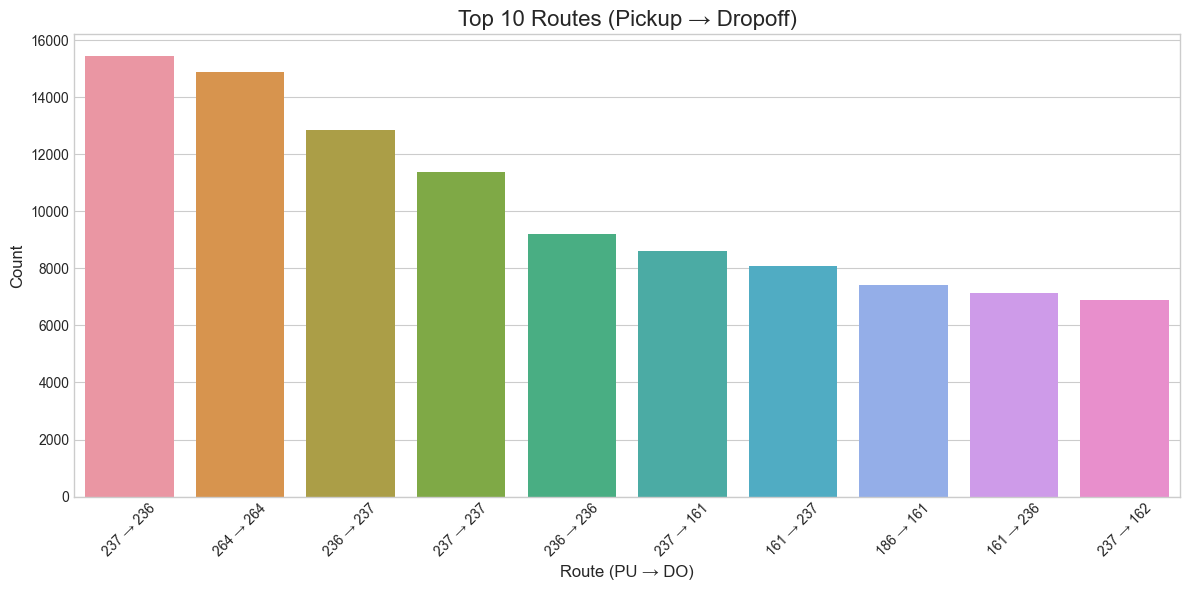

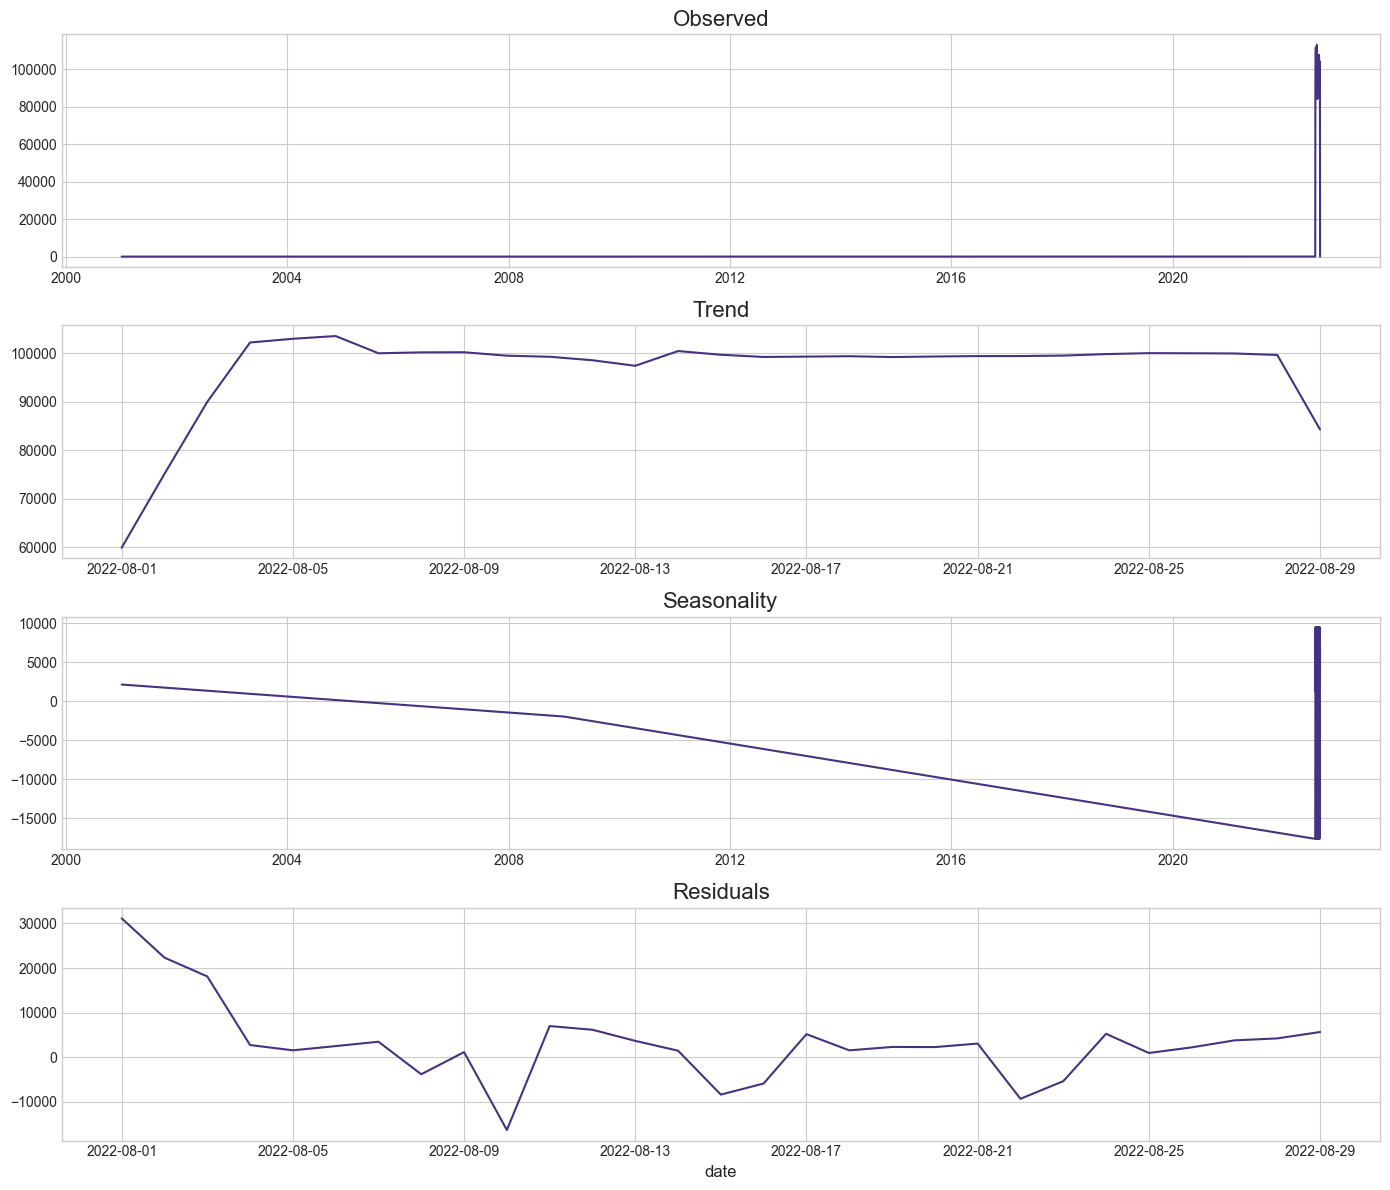

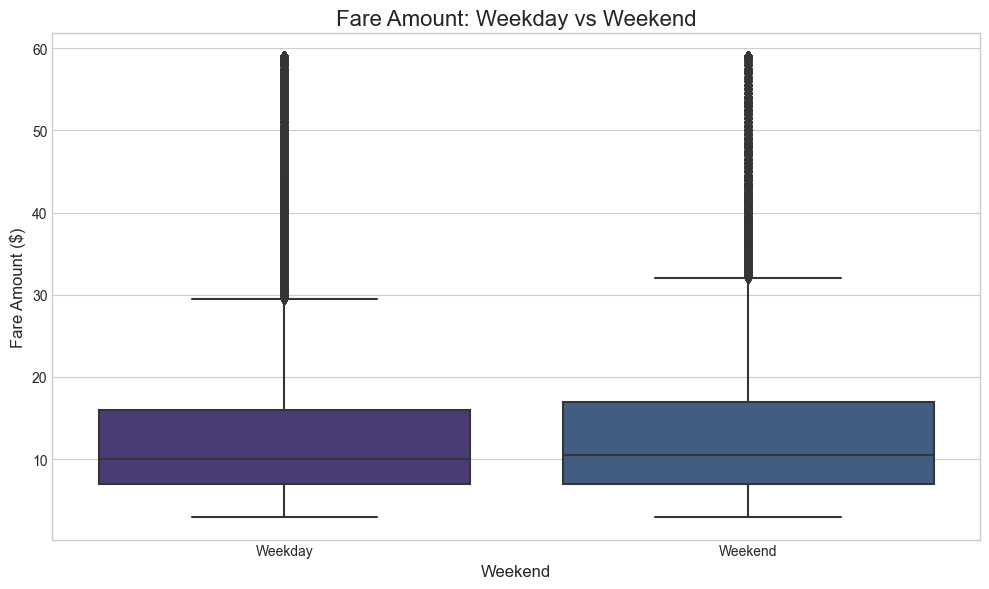

In [ ]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from scipy import stats

# Import the anomaly detection module
# For implementation, you would save the previous code as anomaly_detection.py
# and import it like this:
# from anomaly_detection import *

# For demonstration purposes, we'll assume the functions are defined in the current scope

# %%
# Main entry point to run both EDA and anomaly detection
def main():
    # Replace with your actual file path
    file_path = "taxi-dataset.parquet"
    
    print("=== TAXI DATASET ANALYSIS WITH ANOMALY DETECTION ===")
    print("\nStarting analysis...")
    
    # Run the full EDA with anomaly detection
    df_with_anomalies = perform_full_eda_with_anomaly_detection(file_path)
    
    # Optional: Run time series forecasting with Prophet
    # This requires Prophet to be installed: pip install prophet
    try:
        # Daily forecasting
        daily_counts = df_with_anomalies.groupby('pickup_date').size().reset_index(name='trip_count')
        if len(daily_counts) >= 14:  # Need enough data points for forecasting
            print("\nPerforming time series forecasting with Prophet...")
            forecast, anomalies = forecast_with_prophet(
                df_with_anomalies, 
                target_column='trip_count', 
                period_freq='D', 
                periods_to_forecast=7
            )
            
            # Print summary of forecast anomalies
            if anomalies is not None:
                anomaly_count = anomalies['anomaly'].sum()
                print(f"\n  Prophet detected {anomaly_count} days with anomalous trip counts")
                
                # Print specific anomalous days
                if anomaly_count > 0:
                    print("  Anomalous days:")
                    for _, row in anomalies[anomalies['anomaly']].iterrows():
                        direction = "high" if row['y'] > row['yhat_upper'] else "low"
                        print(f"    {row['ds'].date()}: {row['y']:.0f} trips ({direction}, expected: {row['yhat']:.0f})")
        else:
            print("\nNot enough daily data points for Prophet forecasting")
    except Exception as e:
        print(f"\nProphet forecasting skipped: {str(e)}")
    
    print("\nAnalysis complete! Check the output directory for visualization files.")
    
    return df_with_anomalies

# %%
# Example: Save anomalies to CSV for further investigation
def export_anomalies(df):
    """
    Export anomalies to CSV files for further investigation
    
    Parameters:
    -----------
    df : pandas DataFrame
        Dataframe with anomaly flags
    """
    # Create 'any_anomaly' flag if it doesn't exist
    if 'any_anomaly' not in df.columns:
        anomaly_cols = [col for col in df.columns if col.endswith('_anomaly')]
        df['any_anomaly'] = df[anomaly_cols].any(axis=1)
    
    # Export all anomalies
    all_anomalies = df[df['any_anomaly']].copy()
    all_anomalies.to_csv('all_anomalies.csv', index=False)
    print(f"Exported {len(all_anomalies)} anomalous trips to 'all_anomalies.csv'")
    
    # Export specific types of anomalies
    for col in df.columns:
        if col.endswith('_anomaly') and col != 'any_anomaly':
            if df[col].sum() > 0:
                specific_anomalies = df[df[col]].copy()
                filename = f"{col.replace('_anomaly', '')}_anomalies.csv"
                specific_anomalies.to_csv(filename, index=False)
                print(f"Exported {len(specific_anomalies)} {col.replace('_anomaly', '').replace('_', ' ')} anomalies to '{filename}'")

# Example of how to run the analysis
if __name__ == "__main__":
    # Run the full analysis
    df_with_anomalies = main()
    
    # Export anomalies to CSV
    export_anomalies(df_with_anomalies)